# 10 Deconvolution + Signature Robustness\n
\n
This notebook checks whether spatial coupling signals are stable when using:\n
- raw spot-level scores,\n
- cell2location deconvolution abundances, and\n
- alternative gene signatures.\n
\n
Run top-to-bottom. Deconvolution training is heavy; cached outputs are reused when available.

## A. Setup, Graph, and Raw-Score Controls

In [31]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

from scipy import sparse
from scipy.stats import spearmanr, pearsonr

# Resolve project root robustly (works from notebooks/, project root, or Downloads/).
_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "Spatial HCC",
    Path.cwd().parent / "Spatial HCC",
]
for _root in _candidates:
    if (_root / "GSE238264_RAW").exists() or (_root / "st_adata_scored.h5ad").exists():
        os.chdir(_root)
        break

print("Working directory:", Path.cwd())

OUTDIR = "p03_deconv_robustness_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# Backward-compatible artifact lookup.
st_candidates = [
    Path("outputs/st_adata_processed.h5ad"),
    Path("outputs/st_adata_scored.h5ad"),
    Path("st_adata_scored.h5ad"),
]

sc_candidates = [
    Path("outputs/scRNA_reference_processed.h5ad"),
    Path("outputs/adata_scRNA_processed.h5ad"),
    Path("adata_scRNA_processed.h5ad"),
]

ST_PATH = next((p for p in st_candidates if p.exists()), None)
SC_PATH = next((p for p in sc_candidates if p.exists()), None)

if ST_PATH is None:
    raise FileNotFoundError(
        "Could not find spatial AnnData. Expected one of: "
        + ", ".join(str(x) for x in st_candidates)
    )
if SC_PATH is None:
    raise FileNotFoundError(
        "Could not find scRNA AnnData. Expected one of: "
        + ", ".join(str(x) for x in sc_candidates)
    )

st_adata = sc.read_h5ad(ST_PATH.as_posix())
sc_adata = sc.read_h5ad(SC_PATH.as_posix())

if not st_adata.obs_names.is_unique:
    st_adata.obs_names_make_unique()
if not sc_adata.obs_names.is_unique:
    sc_adata.obs_names_make_unique()

print("Loaded ST_PATH:", ST_PATH)
print("Loaded SC_PATH:", SC_PATH)
print("st_adata:", st_adata.shape)
print("sc_adata:", sc_adata.shape)
print("st_adata obs cols:", list(st_adata.obs.columns)[:15])
print("sc_adata obs cols:", list(sc_adata.obs.columns)[:15])


Working directory: /Users/prateek/Downloads/Spatial HCC


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Loaded ST_PATH: st_adata_scored.h5ad
Loaded SC_PATH: adata_scRNA_processed.h5ad
st_adata: (17292, 22689)
sc_adata: (71915, 3000)
st_adata obs cols: ['in_tissue', 'array_row', 'array_col', 'sample', 'spot_exhaustion', 'spot_cytotoxic', 'spot_tam', 'response', 'spot_caf', 'spot_malignant', 'spot_stemness', 'spot_bcell', 'spot_plasma', 'spot_endo']
sc_adata obs cols: ['sample', 'res.3', 'site', 'patient', 'stage', 'virus', 'celltype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes']


In [32]:
# Ensure spatial coords
if "spatial" not in st_adata.obsm:
    raise KeyError("st_adata.obsm['spatial'] missing. Ensure Visium load preserved spatial coordinates.")

# Graph construction (choose ONE; keep consistent with your paper)
# Option 1: grid-ring (Visium native)
sq.gr.spatial_neighbors(st_adata, coord_type="grid", n_rings=2)  # adjust to match your core notebook

# Option 2: kNN
# sq.gr.spatial_neighbors(st_adata, coord_type="generic", n_neighs=10)

print("Graph keys:", st_adata.obsp.keys())
print("Connectivities shape:", st_adata.obsp["spatial_connectivities"].shape)

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
Graph keys: KeysView(PairwiseArrays with keys: spatial_connectivities, spatial_distances)
Connectivities shape: (17292, 17292)


In [33]:
# Map to your actual column names
COL = dict(
    CAF="spot_caf",
    MAL="spot_malignant",
    CYT="spot_cytotoxic",
    EXH="spot_exhaustion",
    TAM="spot_tam",
    BCELL="spot_bcell",
)

missing = [v for v in COL.values() if v not in st_adata.obs.columns]
if missing:
    raise KeyError(f"Missing expected module-score columns in st_adata.obs: {missing}")

# Simple composition proxies (bounded via softplus)
def softplus(x): 
    return np.log1p(np.exp(x))

caf = softplus(st_adata.obs[COL["CAF"]].values)
mal = softplus(st_adata.obs[COL["MAL"]].values)
cyt = softplus(st_adata.obs[COL["CYT"]].values)
exh = softplus(st_adata.obs[COL["EXH"]].values)

den = caf + mal + cyt + exh + 1e-8
st_adata.obs["proxy_tumor_frac"] = mal / den
st_adata.obs["proxy_stroma_frac"] = caf / den
st_adata.obs["proxy_immune_frac"] = (cyt + exh) / den

print(st_adata.obs[["proxy_tumor_frac","proxy_stroma_frac","proxy_immune_frac"]].describe())

       proxy_tumor_frac  proxy_stroma_frac  proxy_immune_frac
count      17292.000000       17292.000000       17292.000000
mean           0.348891           0.215736           0.435373
std            0.069316           0.086573           0.041580
min            0.134442           0.096683           0.237982
25%            0.301798           0.150310           0.412239
50%            0.354237           0.189442           0.437904
75%            0.397927           0.267566           0.462762
max            0.529695           0.604773           0.609388


In [34]:
import numpy as np
from scipy.stats import pearsonr

def get_edges_from_connectivities(A):
    # A is sparse adjacency (connectivities)
    A = A.tocoo()
    # keep upper triangle to avoid duplication
    mask = A.row < A.col
    return A.row[mask], A.col[mask], A.data[mask]

def field_energy(st_adata, field):
    """Graph total-variation energy: sum w_ij (f_i - f_j)^2"""
    A = st_adata.obsp["spatial_connectivities"]
    i, j, w = get_edges_from_connectivities(A)
    f = np.asarray(field).reshape(-1)
    return np.sum(w * (f[i] - f[j])**2)

def edgewise_coupling(st_adata, field_a, field_b, method="pearson"):
    """Coupling = correlation of edge gradients Δf_a vs Δf_b over edges"""
    A = st_adata.obsp["spatial_connectivities"]
    i, j, w = get_edges_from_connectivities(A)
    a = np.asarray(field_a).reshape(-1)
    b = np.asarray(field_b).reshape(-1)
    da = a[j] - a[i]
    db = b[j] - b[i]
    if method == "pearson":
        r, p = pearsonr(da, db)
    else:
        r, p = spearmanr(da, db)
    return r, p

# sanity check
r_ec, p_ec = edgewise_coupling(st_adata, st_adata.obs[COL["EXH"]], st_adata.obs[COL["CYT"]])
E_caf = field_energy(st_adata, st_adata.obs[COL["CAF"]])
print("Example coupling EXH~CYT:", r_ec, p_ec)
print("Example energy CAF:", E_caf)

Example coupling EXH~CYT: 0.0666526382269973 4.040567042509431e-89
Example energy CAF: 64026.76280259972


In [35]:
def compute_metrics_on_subset(st_adata, mask, label="all"):
    sub = st_adata[mask].copy()
    # rebuild graph on subset (important!)
    sq.gr.spatial_neighbors(sub, coord_type="grid", n_rings=2)

    out = {}
    out["label"] = label
    out["n_spots"] = sub.n_obs
    out["E_CAF"] = field_energy(sub, sub.obs[COL["CAF"]])
    out["C_EXH_CYT"], _ = edgewise_coupling(sub, sub.obs[COL["EXH"]], sub.obs[COL["CYT"]])
    out["C_MAL_CAF"], _ = edgewise_coupling(sub, sub.obs[COL["MAL"]], sub.obs[COL["CAF"]])
    out["C_B_CYT"], _ = edgewise_coupling(sub, sub.obs[COL["BCELL"]], sub.obs[COL["CYT"]])
    return out

# Define filters
m_all = np.ones(st_adata.n_obs, dtype=bool)
m_high_tumor = st_adata.obs["proxy_tumor_frac"].values >= np.quantile(st_adata.obs["proxy_tumor_frac"].values, 0.6)
m_low_tumor  = st_adata.obs["proxy_tumor_frac"].values <= np.quantile(st_adata.obs["proxy_tumor_frac"].values, 0.4)

rows = []
rows.append(compute_metrics_on_subset(st_adata, m_all, "all"))
rows.append(compute_metrics_on_subset(st_adata, m_high_tumor, "high_tumor_frac"))
rows.append(compute_metrics_on_subset(st_adata, m_low_tumor, "low_tumor_frac"))

df_purity_ctrl = pd.DataFrame(rows)
df_purity_ctrl.to_csv(f"{OUTDIR}/purity_filter_controls.csv", index=False)
df_purity_ctrl

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


,label,n_spots,E_CAF,C_EXH_CYT,C_MAL_CAF,C_B_CYT
0,all,17292,64026.762803,0.066653,-0.379416,0.220431
1,high_tumor_frac,6917,4585.974279,-0.001730,0.073138,0.135397
2,low_tumor_frac,6917,18786.108754,0.058031,0.182800,0.132663


## B. Cell2location Deconvolution (Reusable Artifacts)

In [36]:
# Dependency check for the deconvolution section.
import importlib.util

required_modules = {
    "cell2location": "cell2location",
    "scvi": "scvi-tools",
    "pyro": "pyro-ppl",
}

missing = [
    pip_name
    for module_name, pip_name in required_modules.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    raise ModuleNotFoundError(
        "Missing required packages: "
        + ", ".join(missing)
        + "\nInstall in a notebook cell with:\n%pip install "
        + " ".join(sorted(set(missing)))
    )

print("All cell2location dependencies are installed.")


All cell2location dependencies are installed.


In [37]:
import os
from pathlib import Path

import cell2location
from cell2location.models import RegressionModel, Cell2location

CELLTYPE_COL = "celltype"
if CELLTYPE_COL not in sc_adata.obs.columns:
    raise KeyError(f"sc_adata.obs['{CELLTYPE_COL}'] missing. Add cell-type annotations first.")

REF_PATH = Path(OUTDIR) / "scRNA_cell2location_reference.h5ad"

# Reuse a previously trained reference if available.
if REF_PATH.exists():
    sc_ref = sc.read_h5ad(REF_PATH.as_posix())
    if "means_per_cluster_mu_fg" in sc_ref.varm:
        sc_adata = sc_ref
        print(f"Loaded existing reference signatures: {REF_PATH}")

# Train reference model only when signatures are not yet available.
if "means_per_cluster_mu_fg" not in sc_adata.varm:
    if "counts" not in sc_adata.layers:
        sc_adata.layers["counts"] = sc_adata.X.copy()

    sc_train = sc_adata.copy()
    sc.pp.filter_genes(sc_train, min_cells=10)
    sc.pp.filter_cells(sc_train, min_genes=200)

    RegressionModel.setup_anndata(sc_train, labels_key=CELLTYPE_COL, layer="counts")

    ref_model = RegressionModel(sc_train)
    ref_epochs = int(os.getenv("CELL2LOC_REF_EPOCHS", "200"))
    ref_post_samples = int(os.getenv("CELL2LOC_REF_POST_SAMPLES", "500"))
    ref_model.train(max_epochs=ref_epochs, batch_size=2500, train_size=1.0)

    sc_adata = ref_model.export_posterior(
        sc_train,
        sample_kwargs=dict(num_samples=ref_post_samples, batch_size=2500),
    )

    sc_adata.write(REF_PATH.as_posix())
    print(f"Saved reference signatures: {REF_PATH}")
else:
    print("Using reference signatures already present in sc_adata.")


Loaded existing reference signatures: p03_deconv_robustness_outputs/scRNA_cell2location_reference.h5ad
Using reference signatures already present in sc_adata.


In [38]:
from pathlib import Path

DECONV_PATH = Path(OUTDIR) / "st_cell2location_deconvolved.h5ad"

# Reuse existing deconvolution output to avoid retraining on every run.
if DECONV_PATH.exists():
    st_adata = sc.read_h5ad(DECONV_PATH.as_posix())
    print(f"Loaded existing deconvolved st_adata: {DECONV_PATH}")
else:
    if "counts" not in st_adata.layers:
        st_adata.layers["counts"] = st_adata.X.copy()

    if "means_per_cluster_mu_fg" not in sc_adata.varm:
        raise KeyError("Missing sc_adata.varm['means_per_cluster_mu_fg'] from reference export.")

    cell_state_df = sc_adata.varm["means_per_cluster_mu_fg"]
    if not isinstance(cell_state_df, pd.DataFrame):
        if CELLTYPE_COL in sc_adata.obs.columns:
            col_names = sorted(sc_adata.obs[CELLTYPE_COL].astype(str).unique())
        else:
            col_names = [f"ct_{i}" for i in range(cell_state_df.shape[1])]
        cell_state_df = pd.DataFrame(cell_state_df, index=sc_adata.var_names, columns=col_names)

    shared_genes = st_adata.var_names.intersection(cell_state_df.index)
    if len(shared_genes) < 200:
        raise ValueError(
            f"Too few shared genes between ST and reference signatures: {len(shared_genes)}. "
            "Check that both datasets use matching gene symbols."
        )

    st_adata = st_adata[:, shared_genes].copy()
    cell_state_df = cell_state_df.loc[shared_genes]

    print(f"Using {len(shared_genes)} shared genes for cell2location spatial model.")

    Cell2location.setup_anndata(st_adata, layer="counts")

    sp_model = Cell2location(
        st_adata,
        cell_state_df=cell_state_df,
    )

    sp_epochs = int(os.getenv("CELL2LOC_SPATIAL_EPOCHS", "3000"))
    sp_post_samples = int(os.getenv("CELL2LOC_SP_POST_SAMPLES", "200"))
    sp_model.train(max_epochs=sp_epochs, batch_size=None, train_size=1.0)

    st_adata = sp_model.export_posterior(
        st_adata,
        sample_kwargs=dict(num_samples=sp_post_samples, batch_size=None),
    )

    st_adata.write(DECONV_PATH.as_posix())
    print(f"Saved deconvolved st_adata: {DECONV_PATH}")

print("obsm keys:", list(st_adata.obsm.keys()))


Loaded existing deconvolved st_adata: p03_deconv_robustness_outputs/st_cell2location_deconvolved.h5ad
obsm keys: ['means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf']


In [39]:
# Identify abundance key
ABUND_KEY_CANDIDATES = [
    k for k in st_adata.obsm.keys() if "abundance" in k or "cell_abundance" in k
]
print("Candidates:", ABUND_KEY_CANDIDATES)

if not ABUND_KEY_CANDIDATES:
    raise KeyError(
        "No abundance matrix found in st_adata.obsm. Expected a key containing 'abundance'."
    )

ABUND_KEY = ABUND_KEY_CANDIDATES[0]
abund = st_adata.obsm[ABUND_KEY]
print("Abundance shape:", abund.shape)

if "means_per_cluster_mu_fg" in sc_adata.varm and hasattr(sc_adata.varm["means_per_cluster_mu_fg"], "columns"):
    ref_celltypes = list(sc_adata.varm["means_per_cluster_mu_fg"].columns)
elif CELLTYPE_COL in sc_adata.obs.columns:
    ref_celltypes = sorted(sc_adata.obs[CELLTYPE_COL].astype(str).unique())
else:
    ref_celltypes = [f"ct_{i}" for i in range(abund.shape[1])]

# Convert abundance matrix to DataFrame with stable column names.
if hasattr(abund, "columns"):
    abund_df = abund.copy()
else:
    abund_df = pd.DataFrame(abund, index=st_adata.obs_names)
    if len(ref_celltypes) == abund_df.shape[1]:
        abund_df.columns = ref_celltypes
    else:
        abund_df.columns = [f"ct_{i}" for i in range(abund_df.shape[1])]

print("Abundance df columns example:", abund_df.columns[:10].tolist())

MAP = {
    "CAF": ["CAF", "fibroblast", "myofibroblast"],
    "TAM": ["macrophage", "TAM", "monocyte"],
    "CYTO": ["CD8 T", "cytotoxic T", "NK"],
    "EXH": ["exhausted T", "CD8 exhausted", "T_exh"],
    "BCELL": ["B cell", "plasma", "Plasma"],
    "ENDO": ["endothelial"],
    "MALIGNANT": ["tumor", "malignant", "HCC"],
}

def sum_celltypes(df, keys):
    cols = [c for c in df.columns if any(k.lower() in str(c).lower() for k in keys)]
    if not cols:
        return np.zeros(df.shape[0])
    return df[cols].sum(axis=1).values

st_adata.obs["deconv_caf"] = sum_celltypes(abund_df, MAP["CAF"])
st_adata.obs["deconv_tam"] = sum_celltypes(abund_df, MAP["TAM"])
st_adata.obs["deconv_cyto"] = sum_celltypes(abund_df, MAP["CYTO"])
st_adata.obs["deconv_exh"] = sum_celltypes(abund_df, MAP["EXH"])
st_adata.obs["deconv_b"] = sum_celltypes(abund_df, MAP["BCELL"])
st_adata.obs["deconv_malig"] = sum_celltypes(abund_df, MAP["MALIGNANT"])

for c in ["deconv_caf", "deconv_tam", "deconv_cyto", "deconv_exh", "deconv_b", "deconv_malig"]:
    x = st_adata.obs[c].values
    std = x.std()
    st_adata.obs[c + "_z"] = (x - x.mean()) / (std + 1e-8)

print(
    st_adata.obs[
        [
            c + "_z"
            for c in ["deconv_caf", "deconv_tam", "deconv_cyto", "deconv_exh", "deconv_b", "deconv_malig"]
        ]
    ].describe()
)


Candidates: ['means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'stds_cell_abundance_w_sf']
Abundance shape: (17292, 6)
Abundance df columns example: ['meanscell_abundance_w_sf_means_per_cluster_mu_fg_B', 'meanscell_abundance_w_sf_means_per_cluster_mu_fg_Endothelial', 'meanscell_abundance_w_sf_means_per_cluster_mu_fg_Fibroblast', 'meanscell_abundance_w_sf_means_per_cluster_mu_fg_Hepatocyte', 'meanscell_abundance_w_sf_means_per_cluster_mu_fg_Myeloid', 'meanscell_abundance_w_sf_means_per_cluster_mu_fg_T/NK']
       deconv_caf_z  deconv_tam_z  deconv_cyto_z  deconv_exh_z  deconv_b_z  \
count  17292.000000       17292.0   1.729200e+04       17292.0     17292.0   
mean       0.000000           0.0   1.553057e-07           0.0         0.0   
std        1.000029           0.0   1.000029e+00           0.0         0.0   
min       -0.791245           0.0  -1.277132e+00           0.0         0.0   
25%       -0.651227           0.0  -5.677575e-01           0.0    

In [40]:
# Build graph (same as before)
sq.gr.spatial_neighbors(st_adata, coord_type="grid", n_rings=2)

# Couplings on deconvolved fields
C_exh_cyto, _ = edgewise_coupling(st_adata, st_adata.obs["deconv_exh_z"], st_adata.obs["deconv_cyto_z"])
C_exh_tam,  _ = edgewise_coupling(st_adata, st_adata.obs["deconv_exh_z"], st_adata.obs["deconv_tam_z"])
C_malig_caf,_ = edgewise_coupling(st_adata, st_adata.obs["deconv_malig_z"], st_adata.obs["deconv_caf_z"])
C_b_cyto,   _ = edgewise_coupling(st_adata, st_adata.obs["deconv_b_z"], st_adata.obs["deconv_cyto_z"])

E_caf = field_energy(st_adata, st_adata.obs["deconv_caf_z"])
E_exh = field_energy(st_adata, st_adata.obs["deconv_exh_z"])
E_cyto = field_energy(st_adata, st_adata.obs["deconv_cyto_z"])

print("Deconv couplings:")
print("C_exh_cyto", C_exh_cyto)
print("C_exh_tam", C_exh_tam)
print("C_malig_caf", C_malig_caf)
print("C_b_cyto", C_b_cyto)
print("Deconv energies:", dict(E_caf=E_caf, E_exh=E_exh, E_cyto=E_cyto))

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
Deconv couplings:
C_exh_cyto nan
C_exh_tam nan
C_malig_caf nan
C_b_cyto nan
Deconv energies: {'E_caf': np.float32(173235.22), 'E_exh': np.float64(0.0), 'E_cyto': np.float32(187777.84)}


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)


## C. Signature Robustness on Spatial Graph

In [41]:
# Example: add multiple signature variants per program (you will expand this)
SIGNATURES = {
    "EXH_v1": ["PDCD1","LAG3","HAVCR2","TIGIT","CTLA4","TOX"],
    "CYT_v1": ["GZMB","GZMK","PRF1","NKG7","GNLY"],
    "CAF_v1": ["COL1A1","COL1A2","COL3A1","DCN","LUM","TAGLN","ACTA2"],
    "TAM_v1": ["C1QC","C1QB","C1QA","APOE","LGALS3","SPP1","MRC1","CD163"],
    "B_v1":   ["MS4A1","CD79A","CD74","HLA-DRA","BANK1","CD37"],
}

# Use scanpy score_genes with controlled gene pools
def score_signature(adata, sig_name, genes, layer=None):
    genes_present = [g for g in genes if g in adata.var_names]
    if len(genes_present) < max(3, int(0.5*len(genes))):
        # too few genes found => return NaN vector
        adata.obs[sig_name] = np.nan
        return len(genes_present)
    sc.tl.score_genes(adata, gene_list=genes_present, score_name=sig_name, use_raw=False, layer=layer)
    return len(genes_present)

# Compute scores
found = {}
for name, genes in SIGNATURES.items():
    n = score_signature(st_adata, name, genes, layer=None)
    found[name] = n

print("Genes found per signature:", found)

# Standardize within sample if you concatenate multi samples later.
for name in SIGNATURES.keys():
    x = st_adata.obs[name].values.astype(float)
    if np.all(np.isnan(x)):
        continue
    st_adata.obs[name+"_z"] = (x - np.nanmean(x)) / (np.nanstd(x) + 1e-8)

Genes found per signature: {'EXH_v1': 5, 'CYT_v1': 5, 'CAF_v1': 7, 'TAM_v1': 7, 'B_v1': 5}


In [42]:
pairs = [
    ("EXH_v1_z", "CYT_v1_z", "EXH_vs_CYTO"),
    ("EXH_v1_z", "TAM_v1_z", "EXH_vs_TAM"),
    ("CAF_v1_z", "TAM_v1_z", "CAF_vs_TAM"),
]

rows = []
for a, b, label in pairs:
    if a not in st_adata.obs.columns or b not in st_adata.obs.columns:
        continue
    r, p = edgewise_coupling(st_adata, st_adata.obs[a], st_adata.obs[b])
    rows.append(dict(pair=label, coupling=r, p=p, sig_a=a, sig_b=b, n_spots=st_adata.n_obs))

df_sig = pd.DataFrame(rows)
df_sig.to_csv(f"{OUTDIR}/signature_robustness_couplings.csv", index=False)
df_sig

,pair,coupling,p,sig_a,sig_b,n_spots
0,EXH_vs_CYTO,0.031266,6.542304e-21,EXH_v1_z,CYT_v1_z,17292
1,EXH_vs_TAM,0.021215,1.961557e-10,EXH_v1_z,TAM_v1_z,17292
2,CAF_vs_TAM,0.391349,0.000000e+00,CAF_v1_z,TAM_v1_z,17292


## D. Patient-Level Tables and Plots

In [43]:
# patient-level aggregation (mean coupling/energy per sample)
if "sample" not in st_adata.obs.columns:
    raise KeyError("st_adata.obs['sample'] missing. Add sample ID per spot.")

# Build group if missing: prefer explicit response labels, then sample suffix fallback.
if "group" not in st_adata.obs.columns:
    if "response" in st_adata.obs.columns:
        _resp = st_adata.obs["response"].astype(str).str.strip().str.lower()
        st_adata.obs["group"] = np.where(_resp.str.contains("non"), "NR", "R")
    else:
        _sample = st_adata.obs["sample"].astype(str).str.upper()
        st_adata.obs["group"] = np.where(_sample.str.endswith("NR"), "NR", "R")

if "group" not in st_adata.obs.columns:
    raise KeyError("st_adata.obs['group'] missing. Add R/NR per spot.")

def patient_level_metrics(adata, use_deconv=False):
    rows = []
    for sid in adata.obs["sample"].astype(str).unique():
        mask = adata.obs["sample"].astype(str).values == sid
        sub = adata[mask].copy()
        sq.gr.spatial_neighbors(sub, coord_type="grid", n_rings=2)

        if use_deconv:
            exh = sub.obs["deconv_exh_z"]
            cyt = sub.obs["deconv_cyto_z"]
            tam = sub.obs["deconv_tam_z"]
            caf = sub.obs["deconv_caf_z"]
            mal = sub.obs["deconv_malig_z"]
            b = sub.obs["deconv_b_z"]
        else:
            exh = sub.obs[COL["EXH"]]
            cyt = sub.obs[COL["CYT"]]
            tam = sub.obs[COL["TAM"]]
            caf = sub.obs[COL["CAF"]]
            mal = sub.obs[COL["MAL"]]
            b = sub.obs[COL["BCELL"]]

        row = {}
        row["sample"] = sid
        row["group"] = sub.obs["group"].iloc[0]
        row["n_spots"] = sub.n_obs

        row["E_CAF"] = field_energy(sub, caf)
        row["C_exh_cyto"], _ = edgewise_coupling(sub, exh, cyt)
        row["C_exh_tam"], _ = edgewise_coupling(sub, exh, tam)
        row["C_malig_caf"], _ = edgewise_coupling(sub, mal, caf)
        row["C_b_cyto"], _ = edgewise_coupling(sub, b, cyt)
        rows.append(row)

    return pd.DataFrame(rows)

df_patient_raw = patient_level_metrics(st_adata, use_deconv=False)
df_patient_raw.to_csv(f"{OUTDIR}/Table_S_patient_metrics_rawscores.csv", index=False)

if "deconv_caf_z" in st_adata.obs.columns:
    df_patient_deconv = patient_level_metrics(st_adata, use_deconv=True)
    df_patient_deconv.to_csv(f"{OUTDIR}/Table_S_patient_metrics_deconv.csv", index=False)

print(df_patient_raw)


INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform an

/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)


INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
   sample group  n_spots         E_CAF  C_exh_cyto  C_exh_tam  C_malig_caf  \
0  HCC5NR    NR     1320    209.850689   -0.031411   0.034104    -0.087547   
1  HCC6NR    NR     2575   3475.921915   -0.008823   0.007545    -0.132147   
2   HCC2R     R     2766  11962.729973   -0.002465   0.053075    -0.063762   
3   HCC1R     R     3006   7517.072738    0.028453   0.034693    -0.037996   
4  HCC7NR    NR     2453   1435.492347   -0.025791   0.050503    -0.105304   
5   HCC3R     R     2170   2852.562649   -0.013435   0.021316    -0.062492   
6   HCC4R     R     3002   4504.981101    0.107690   0.036228    -0.040763   

   C_b_cyto  
0  0.037652  
1  0.076387  
2  0.028006  
3  0.056450  
4  0.023197  
5  0.024904  
6  0.141653  


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)


In [44]:
import matplotlib.pyplot as plt

def boxplot_metric(df, col, fname):
    fig = plt.figure()
    groups = [df[df["group"]=="R"][col].values, df[df["group"]=="NR"][col].values]
    plt.boxplot(groups, labels=["R","NR"])
    plt.title(col)
    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    plt.close(fig)

# Raw-score patient plots
boxplot_metric(df_patient_raw, "E_CAF", f"{OUTDIR}/FigS_raw_E_CAF_R_vs_NR.png")
boxplot_metric(df_patient_raw, "C_malig_caf", f"{OUTDIR}/FigS_raw_C_malig_caf_R_vs_NR.png")
boxplot_metric(df_patient_raw, "C_exh_cyto", f"{OUTDIR}/FigS_raw_C_exh_cyto_R_vs_NR.png")

# Deconv plots if available
if "deconv_caf_z" in st_adata.obs.columns:
    boxplot_metric(df_patient_deconv, "E_CAF", f"{OUTDIR}/FigS_deconv_E_CAF_R_vs_NR.png")
    boxplot_metric(df_patient_deconv, "C_malig_caf", f"{OUTDIR}/FigS_deconv_C_malig_caf_R_vs_NR.png")
    boxplot_metric(df_patient_deconv, "C_exh_cyto", f"{OUTDIR}/FigS_deconv_C_exh_cyto_R_vs_NR.png")

print("Saved figures into:", OUTDIR)

/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/3446273996.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["R","NR"])
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/3446273996.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["R","NR"])
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/3446273996.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["R","NR"])
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/3446273996.py:6: MatplotlibDeprecationWarning: The 'labels'

Saved figures into: p03_deconv_robustness_outputs


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/3446273996.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["R","NR"])
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/3446273996.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["R","NR"])


## E. Optional Hybrid Coupling (Safe Column Fallbacks)\n
This replaces the previous ad-hoc debug cells and avoids hard-coded missing names like `exhaustion_z`.

In [45]:
# Optional hybrid coupling summary with robust column fallbacks.

def first_existing_col(adata, candidates):
    for c in candidates:
        if c in adata.obs.columns:
            return c
    return None

# Prefer signature z-scores for exhaustion; otherwise fall back to raw/deconv columns.
exh_col = first_existing_col(st_adata, ["EXH_v1_z", "spot_exhaustion", "deconv_exh_z", "exhaustion_z"])
mal_col = first_existing_col(st_adata, ["spot_malignant", "deconv_malig_z", "malignant_z"])
caf_col = first_existing_col(st_adata, ["deconv_caf_z", "spot_caf"])
cyto_col = first_existing_col(st_adata, ["deconv_cyto_z", "spot_cytotoxic"])
tam_col = first_existing_col(st_adata, ["deconv_tam_z", "spot_tam"])
b_col = first_existing_col(st_adata, ["deconv_b_z", "deconv_bcell_z", "spot_bcell"])

required = {
    "exh": exh_col,
    "mal": mal_col,
    "caf": caf_col,
    "cyto": cyto_col,
    "tam": tam_col,
    "b": b_col,
}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise KeyError(f"Missing required columns for hybrid summary: {missing}. Available obs columns include: {list(st_adata.obs.columns)[:20]} ...")

# Ensure graph exists after any st_adata reload.
if "spatial_connectivities" not in st_adata.obsp:
    sq.gr.spatial_neighbors(st_adata, coord_type="grid", n_rings=2)

hybrid_metrics = {
    "EXH_col": exh_col,
    "MAL_col": mal_col,
    "CAF_col": caf_col,
    "CYTO_col": cyto_col,
    "TAM_col": tam_col,
    "B_col": b_col,
}

hybrid_metrics["C_exh_cyto"], _ = edgewise_coupling(st_adata, st_adata.obs[exh_col], st_adata.obs[cyto_col])
hybrid_metrics["C_exh_tam"], _ = edgewise_coupling(st_adata, st_adata.obs[exh_col], st_adata.obs[tam_col])
hybrid_metrics["C_malig_caf"], _ = edgewise_coupling(st_adata, st_adata.obs[mal_col], st_adata.obs[caf_col])
hybrid_metrics["C_b_cyto"], _ = edgewise_coupling(st_adata, st_adata.obs[b_col], st_adata.obs[cyto_col])
hybrid_metrics["E_caf"] = field_energy(st_adata, st_adata.obs[caf_col])

pd.Series(hybrid_metrics, name="hybrid_summary")


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/4191810127.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(da, db)


EXH_col              EXH_v1_z
MAL_col        spot_malignant
CAF_col          deconv_caf_z
CYTO_col        deconv_cyto_z
TAM_col          deconv_tam_z
B_col              deconv_b_z
C_exh_cyto           0.142262
C_exh_tam                 NaN
C_malig_caf         -0.194219
C_b_cyto                  NaN
E_caf            173235.21875
Name: hybrid_summary, dtype: object

In [ ]:
# Scale sensitivity analysis for neighborhood size (kNN graph).

# Local fallback helper (safe if earlier helper cell was not run).
def _first_existing_col(adata, candidates):
    for c in candidates:
        if c in adata.obs.columns:
            return c
    return None

# Resolve robust column names from currently available fields.
exh_col = _first_existing_col(st_adata, ["EXH_v1_z", "spot_exhaustion", "deconv_exh_z", "exhaustion_z"])
mal_col = _first_existing_col(st_adata, ["spot_malignant", "deconv_malig_z", "malignant_z"])
caf_col = _first_existing_col(st_adata, ["deconv_caf_z", "spot_caf"])
cyto_col = _first_existing_col(st_adata, ["deconv_cyto_z", "spot_cytotoxic"])
b_col = _first_existing_col(st_adata, ["deconv_b_z", "deconv_bcell_z", "spot_bcell"])

missing = [name for name, col in {
    "exh": exh_col,
    "mal": mal_col,
    "caf": caf_col,
    "cyto": cyto_col,
    "b": b_col,
}.items() if col is None]
if missing:
    raise KeyError(f"Missing required columns for scale sensitivity: {missing}")

if "group" not in st_adata.obs.columns:
    if "response" in st_adata.obs.columns:
        _resp = st_adata.obs["response"].astype(str).str.strip().str.lower()
        st_adata.obs["group"] = np.where(_resp.str.contains("non"), "NR", "R")
    else:
        _sample = st_adata.obs["sample"].astype(str).str.upper()
        st_adata.obs["group"] = np.where(_sample.str.endswith("NR"), "NR", "R")

scales = [1, 2, 3, 5]
results = []

for k in scales:
    for sample in st_adata.obs["sample"].astype(str).unique():
        mask = st_adata.obs["sample"].astype(str).values == sample
        ad = st_adata[mask].copy()

        # Build graph per sample to avoid cross-sample edges.
        sq.gr.spatial_neighbors(ad, coord_type="generic", n_neighs=k)

        c_exh_cyto, p_exh_cyto = edgewise_coupling(ad, ad.obs[exh_col], ad.obs[cyto_col])
        c_malig_caf, p_malig_caf = edgewise_coupling(ad, ad.obs[mal_col], ad.obs[caf_col])
        c_b_cyto, p_b_cyto = edgewise_coupling(ad, ad.obs[b_col], ad.obs[cyto_col])
        e_caf = field_energy(ad, ad.obs[caf_col])

        # Keep the same a priori SICI definition used in notebook 03.
        sici = c_b_cyto - c_malig_caf - c_exh_cyto

        results.append({
            "sample": sample,
            "group": ad.obs["group"].iloc[0],
            "scale": k,
            "C_exh_cyto": c_exh_cyto,
            "P_exh_cyto": p_exh_cyto,
            "C_malig_caf": c_malig_caf,
            "P_malig_caf": p_malig_caf,
            "C_b_cyto": c_b_cyto,
            "P_b_cyto": p_b_cyto,
            "E_CAF": e_caf,
            "SICI": sici,
        })

df_scale = pd.DataFrame(results)
df_scale.to_csv(f"{OUTDIR}/scale_sensitivity_couplings.csv", index=False)
df_scale.head()


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

if "df_scale" not in globals() or df_scale.empty:
    raise ValueError("df_scale is empty. Run the previous scale-sensitivity cell first.")

fig = plt.figure(figsize=(8, 4))
sns.boxplot(data=df_scale, x="scale", y="C_exh_cyto", hue="group")
plt.title("Scale Sensitivity: C_exh_cyto")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/FigS_scale_sensitivity_C_exh_cyto.png", dpi=300)
plt.close(fig)

fig = plt.figure(figsize=(8, 4))
sns.boxplot(data=df_scale, x="scale", y="C_malig_caf", hue="group")
plt.title("Scale Sensitivity: C_malig_caf")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/FigS_scale_sensitivity_C_malig_caf.png", dpi=300)
plt.close(fig)

print(f"Saved scale sensitivity table/plots in: {OUTDIR}")


Saved scale sensitivity table/plots in: p03_deconv_robustness_outputs


In [53]:

df_scale.groupby(["scale","group"])["sample"].nunique()
df_scale["sample"].nunique(), df_scale["scale"].nunique()


(7, 4)

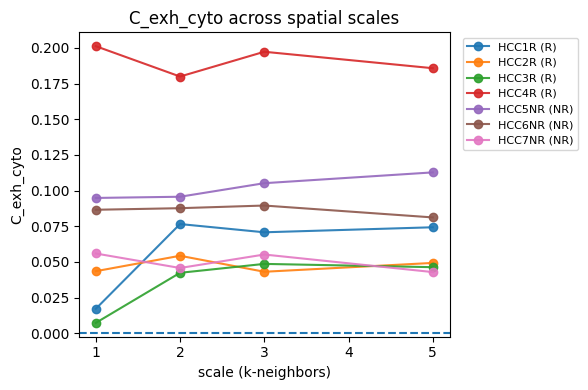

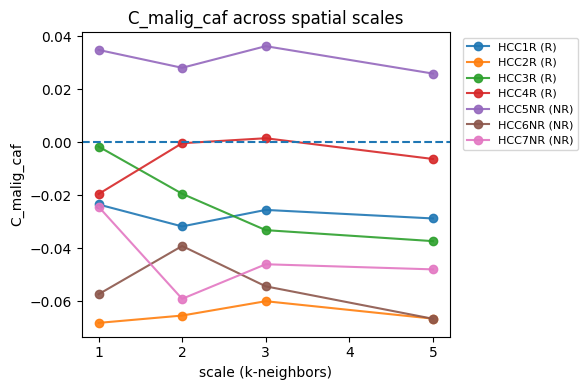

In [54]:

import matplotlib.pyplot as plt

for metric in ["C_exh_cyto", "C_malig_caf"]:
    plt.figure(figsize=(6,4))
    for s, sub in df_scale.sort_values("scale").groupby("sample"):
        g = sub["group"].iloc[0]
        plt.plot(sub["scale"], sub[metric], marker="o", linestyle="-", alpha=0.9, label=f"{s} ({g})")
    plt.axhline(0, linestyle="--")
    plt.xlabel("scale (k-neighbors)")
    plt.ylabel(metric)
    plt.title(f"{metric} across spatial scales")
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [55]:
import numpy as np

def perm_group_diff(df, metric, n_perm=20000, seed=0):
    rng = np.random.default_rng(seed)
    x = df[metric].values
    g = df["group"].values
    obs = x[g=="R"].mean() - x[g=="NR"].mean()
    cnt = 0
    for _ in range(n_perm):
        gp = rng.permutation(g)
        diff = x[gp=="R"].mean() - x[gp=="NR"].mean()
        if abs(diff) >= abs(obs):
            cnt += 1
    return obs, (cnt+1)/(n_perm+1)

rows = []
for sc, sub in df_scale.groupby("scale"):
    for metric in ["C_exh_cyto", "C_malig_caf"]:
        diff, p = perm_group_diff(sub, metric)
        rows.append({"scale": sc, "metric": metric, "diff_R_minus_NR": diff, "p_perm": p})
df_scale_summary = pd.DataFrame(rows).sort_values(["metric","scale"])
df_scale_summary

,scale,metric,diff_R_minus_NR,p_perm
0,1,C_exh_cyto,-0.011825,0.913254
2,2,C_exh_cyto,0.011928,0.913004
4,3,C_exh_cyto,0.006653,0.970001
6,5,C_exh_cyto,0.009980,0.912004
1,1,C_malig_caf,-0.012599,0.740213
3,2,C_malig_caf,-0.005863,0.884056
5,3,C_malig_caf,-0.007914,0.795460
7,5,C_malig_caf,-0.005184,0.914804


In [56]:
def sign_flip_summary(df, metric):
    out=[]
    for s, sub in df.sort_values("scale").groupby("sample"):
        signs = np.sign(sub[metric].values)
        flips = np.sum(signs[1:] != signs[:-1])
        out.append({"sample": s, "group": sub["group"].iloc[0], "n_flips": flips})
    return pd.DataFrame(out)

sign_flip_summary(df_scale, "C_exh_cyto")
sign_flip_summary(df_scale, "C_malig_caf")

,sample,group,n_flips
0,HCC1R,R,0
1,HCC2R,R,0
2,HCC3R,R,0
3,HCC4R,R,2
4,HCC5NR,NR,0
5,HCC6NR,NR,0
6,HCC7NR,NR,0


In [58]:
from pathlib import Path

# If this cell is run after an old df_scale build, enrich from patient-level outputs.
df_scale_eval = df_scale.copy()

fallback_source = None
if "df_patient_raw" in globals() and isinstance(df_patient_raw, pd.DataFrame):
    fallback_source = df_patient_raw.copy()
else:
    p_raw = Path(OUTDIR) / "Table_S_patient_metrics_rawscores.csv"
    if p_raw.exists():
        fallback_source = pd.read_csv(p_raw)

if fallback_source is not None:
    keep = ["sample", "E_CAF", "C_b_cyto", "C_malig_caf", "C_exh_cyto"]
    keep = [c for c in keep if c in fallback_source.columns]
    if "sample" in keep and len(keep) > 1:
        extra = fallback_source[keep].drop_duplicates("sample")
        df_scale_eval = df_scale_eval.merge(extra, on="sample", how="left", suffixes=("", "_raw"))
        for c in ["E_CAF", "C_b_cyto", "C_malig_caf", "C_exh_cyto"]:
            raw_c = f"{c}_raw"
            if c not in df_scale_eval.columns and raw_c in df_scale_eval.columns:
                df_scale_eval[c] = df_scale_eval[raw_c]
            elif c in df_scale_eval.columns and raw_c in df_scale_eval.columns:
                df_scale_eval[c] = df_scale_eval[c].fillna(df_scale_eval[raw_c])

# Compute SICI if missing and dependencies are available.
if "SICI" not in df_scale_eval.columns:
    req = ["C_b_cyto", "C_malig_caf", "C_exh_cyto"]
    if all(c in df_scale_eval.columns for c in req):
        df_scale_eval["SICI"] = (
            df_scale_eval["C_b_cyto"]
            - df_scale_eval["C_malig_caf"]
            - df_scale_eval["C_exh_cyto"]
        )

metrics = ["SICI", "E_CAF"]
available_metrics = [m for m in metrics if m in df_scale_eval.columns]
missing_metrics = [m for m in metrics if m not in df_scale_eval.columns]
if missing_metrics:
    print("Skipping missing metrics:", missing_metrics)

if not available_metrics:
    raise KeyError(
        "No requested metrics available for permutation test. "
        "Run cell 21 again or ensure df_patient_raw export is present."
    )

rows = []
for sc, sub in df_scale_eval.groupby("scale"):
    for metric in available_metrics:
        diff, p = perm_group_diff(sub, metric, n_perm=20000, seed=0)
        rows.append({"scale": sc, "metric": metric, "diff_R_minus_NR": diff, "p_perm": p})

df_scale_summary2 = pd.DataFrame(rows).sort_values(["metric", "scale"])
df_scale_summary2


,scale,metric,diff_R_minus_NR,p_perm
1,1,E_CAF,5002.248299,0.140843
3,2,E_CAF,5002.248299,0.140843
5,3,E_CAF,5002.248299,0.140843
7,5,E_CAF,5002.248299,0.140843
0,1,SICI,0.041432,0.395880
2,2,SICI,0.010943,0.766362
4,3,SICI,0.018269,0.654817
6,5,SICI,0.012212,0.856457


In [60]:
sorted([c for c in df_patient_raw.columns if "exh" in c.lower() and "cyto" in c.lower()])

['C_exh_cyto']

In [73]:
import numpy as np
import pandas as pd
import re

# 1) robust matcher with diagnostics
def match_cols(df, keys):
    keys_l = [k.lower() for k in keys]
    cols = [c for c in df.columns if any(k in str(c).lower() for k in keys_l)]
    return cols

def sum_celltypes_df(df, keys, name, strict=False):
    cols = match_cols(df, keys)
    print(f"[{name}] matched {len(cols)} cols:", cols[:6], ("..." if len(cols) > 6 else ""))
    if (not cols) and strict:
        raise ValueError(f"No columns matched for {name}. Keys={keys}. Available cols={list(df.columns)[:15]}")
    if not cols:
        return np.zeros(df.shape[0], dtype=float)
    return df[cols].sum(axis=1).values

# 2) UPDATED MAP aligned to your cell2location output names
MAP2 = {
    "CAF":      ["fibroblast"],      # matches "..._Fibroblast"
    "TAM":      ["myeloid"],          # matches "..._Myeloid"
    "CYTO":     ["t/nk", "t_nk"],     # matches "..._T/NK"
    "BCELL":    ["_b", " b"],         # matches "..._B" (safe-ish)
    "ENDO":     ["endothelial"],      # matches "..._Endothelial"
    # NOTE: malignant/exhaustion are NOT present as celltypes in this reference
    # we'll create surrogates or keep them as NaN and explicitly state limitation
}

st_adata.obs["deconv_caf"]  = sum_celltypes_df(abund_df, MAP2["CAF"],  "CAF",  strict=True)
st_adata.obs["deconv_tam"]  = sum_celltypes_df(abund_df, MAP2["TAM"],  "TAM",  strict=True)
st_adata.obs["deconv_cyto"] = sum_celltypes_df(abund_df, MAP2["CYTO"], "CYTO", strict=True)
st_adata.obs["deconv_b"]    = sum_celltypes_df(abund_df, MAP2["BCELL"],"B",    strict=False)
st_adata.obs["deconv_endo"] = sum_celltypes_df(abund_df, MAP2["ENDO"], "ENDO", strict=True)

# 3) Exhaustion + malignant: not identifiable from this reference → set as NaN (NOT zero)
st_adata.obs["deconv_exh"]   = np.nan
st_adata.obs["deconv_malig"] = np.nan

# 4) sanity checks (critical)
for c in ["deconv_caf","deconv_tam","deconv_cyto","deconv_b","deconv_endo"]:
    print(c, "std=", float(np.nanstd(st_adata.obs[c].values)), "min/max=", float(np.nanmin(st_adata.obs[c].values)), float(np.nanmax(st_adata.obs[c].values)))

# 5) z-score only for non-constant cols
def safe_z(x):
    x = np.asarray(x, dtype=float)
    m = np.nanmean(x)
    s = np.nanstd(x)
    if (not np.isfinite(s)) or s < 1e-12:
        return np.full_like(x, np.nan)
    return (x - m) / s

for c in ["deconv_caf","deconv_tam","deconv_cyto","deconv_b","deconv_endo"]:
    st_adata.obs[c+"_z"] = safe_z(st_adata.obs[c].values)

[CAF] matched 1 cols: ['meanscell_abundance_w_sf_means_per_cluster_mu_fg_Fibroblast'] 
[TAM] matched 1 cols: ['meanscell_abundance_w_sf_means_per_cluster_mu_fg_Myeloid'] 
[CYTO] matched 1 cols: ['meanscell_abundance_w_sf_means_per_cluster_mu_fg_T/NK'] 
[B] matched 1 cols: ['meanscell_abundance_w_sf_means_per_cluster_mu_fg_B'] 
[ENDO] matched 1 cols: ['meanscell_abundance_w_sf_means_per_cluster_mu_fg_Endothelial'] 
deconv_caf std= 0.37023037672042847 min/max= 0.1771935671567917 4.713310241699219
deconv_tam std= 0.19248883426189423 min/max= 0.173594132065773 4.055810928344727
deconv_cyto std= 0.14469724893569946 min/max= 0.16468597948551178 3.3309261798858643
deconv_b std= 0.2506636679172516 min/max= 0.17176541686058044 6.467587471008301
deconv_endo std= 0.16507317125797272 min/max= 0.19319996237754822 2.4310247898101807


In [74]:
import numpy as np
import pandas as pd

FIELDS = {
    "CAF":  st_adata.obs["deconv_caf_z"].values,
    "TAM":  st_adata.obs["deconv_tam_z"].values,
    "CYTO": st_adata.obs["deconv_cyto_z"].values,
    "B":    st_adata.obs["deconv_b_z"].values,
    "ENDO": st_adata.obs["deconv_endo_z"].values,
}

In [75]:
import scipy.sparse as sp

def field_energy(x, L):
    # x: (n_spots,) z-scored
    x = np.asarray(x, dtype=float)
    return float(x.T @ (L @ x))

# Example: L should be precomputed for each sample separately
# We'll compute per-sample below

In [64]:
def coupling_edge_grad_corr(x, y, edges, w=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    i = edges[:,0]; j = edges[:,1]
    dx = x[j] - x[i]
    dy = y[j] - y[i]

    if w is not None:
        w = np.asarray(w, dtype=float)
        dx = dx * np.sqrt(w)
        dy = dy * np.sqrt(w)

    # Pearson corr (robust to scale)
    sx = dx.std()
    sy = dy.std()
    if sx < 1e-12 or sy < 1e-12:
        return np.nan
    return float(np.corrcoef(dx, dy)[0,1])

In [76]:
def coupling_edge_grad_corr(x, y, edges, w=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    i = edges[:,0]; j = edges[:,1]
    dx = x[j] - x[i]
    dy = y[j] - y[i]

    if w is not None:
        w = np.asarray(w, dtype=float)
        dx = dx * np.sqrt(w)
        dy = dy * np.sqrt(w)

    # Pearson corr (robust to scale)
    sx = dx.std()
    sy = dy.std()
    if sx < 1e-12 or sy < 1e-12:
        return np.nan
    return float(np.corrcoef(dx, dy)[0,1])

In [77]:
pairs = [
    ("CAF","CYTO"),
    ("CAF","TAM"),
    ("TAM","CYTO"),
    ("CAF","B"),
    ("CYTO","ENDO"),
    ("TAM","ENDO"),
]

rows = []
for sample in st_adata.obs["sample"].astype(str).unique():
    ad = st_adata[st_adata.obs["sample"].astype(str) == sample].copy()

    # Ensure group exists for this sample.
    if "group" in ad.obs.columns:
        grp = ad.obs["group"].iloc[0]
    elif "response" in ad.obs.columns:
        resp = str(ad.obs["response"].iloc[0]).strip().lower()
        grp = "NR" if "non" in resp else "R"
    else:
        grp = "NR" if sample.upper().endswith("NR") else "R"

    # --- Build graph for THIS sample (same method as core pipeline) ---
    sq.gr.spatial_neighbors(ad, coord_type="grid", n_rings=2)

    # Weighted adjacency from squidpy graph.
    A = ad.obsp["spatial_connectivities"].tocsr().astype(float)
    A = ((A + A.T) * 0.5).tocsr()  # enforce symmetry
    A.setdiag(0.0)
    A.eliminate_zeros()

    # Upper-triangle edges (i < j) and optional edge weights.
    U = sp.triu(A, k=1).tocoo()
    edges = np.column_stack([U.row, U.col]).astype(int)
    w = U.data.astype(float)

    # Graph Laplacian L = D - A for energy computations.
    deg = np.asarray(A.sum(axis=1)).ravel()
    L = sp.diags(deg) - A

    # Persist on sample object for reproducibility/debugging.
    ad.uns["edges"] = edges
    ad.uns["edge_w"] = w
    ad.uns["L"] = L

    # --- Energies ---
    for prog in FIELDS.keys():
        xs = ad.obs[f"deconv_{prog.lower()}_z"].values
        E = field_energy(xs, L)
        rows.append({"sample": sample, "group": grp, "metric": f"E_{prog}", "value": E})

    # --- Couplings ---
    for a, b in pairs:
        xa = ad.obs[f"deconv_{a.lower()}_z"].values
        xb = ad.obs[f"deconv_{b.lower()}_z"].values
        C = coupling_edge_grad_corr(xa, xb, edges, w=w)
        rows.append({"sample": sample, "group": grp, "metric": f"C_{a}_{b}", "value": C})

df_deconv_metrics = pd.DataFrame(rows)
df_deconv_metrics.to_csv("Table_S_patient_metrics_deconv_RECOMPUTED.csv", index=False)
df_deconv_metrics.head()


INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


,sample,group,metric,value
0,HCC5NR,NR,E_CAF,15.419152
1,HCC5NR,NR,E_TAM,218.307156
2,HCC5NR,NR,E_CYTO,526.819135
3,HCC5NR,NR,E_B,62.570442
4,HCC5NR,NR,E_ENDO,275.546271


In [67]:
import itertools

def exact_label_perm_pvalue(values, groups):
    values = np.asarray(values, float)
    groups = np.asarray(groups)
    idx_R = np.where(groups=="R")[0]
    idx_NR = np.where(groups=="NR")[0]
    obs = values[idx_R].mean() - values[idx_NR].mean()

    n = len(groups)
    nR = len(idx_R)
    diffs = []
    for Rset in itertools.combinations(range(n), nR):
        Rset = np.array(Rset)
        NRset = np.array([i for i in range(n) if i not in set(Rset)])
        diffs.append(values[Rset].mean() - values[NRset].mean())
    diffs = np.array(diffs)

    p = (np.sum(np.abs(diffs) >= np.abs(obs)) + 1) / (len(diffs) + 1)
    return obs, p

summary = []
for metric in sorted(df_deconv_metrics["metric"].unique()):
    sub = df_deconv_metrics[df_deconv_metrics["metric"]==metric].copy()
    # patient-level single value per sample assumed
    wide = sub.pivot_table(index=["sample","group"], values="value", aggfunc="mean").reset_index()
    obs, p = exact_label_perm_pvalue(wide["value"].values, wide["group"].values)
    summary.append({"metric":metric, "diff_R_minus_NR":obs, "p_exact":p})

df_deconv_tests = pd.DataFrame(summary).sort_values("p_exact")
df_deconv_tests

,metric,diff_R_minus_NR,p_exact
6,E_B,27735.102524,0.083333
10,E_TAM,31294.005740,0.111111
7,E_CAF,11676.908753,0.194444
8,E_CYTO,22958.484122,0.222222
2,C_CAF_TAM,0.093778,0.333333
3,C_CYTO_ENDO,-0.139022,0.333333
9,E_ENDO,10068.564821,0.416667
1,C_CAF_CYTO,0.111631,0.500000
0,C_CAF_B,0.085622,0.583333
4,C_TAM_CYTO,-0.026807,0.666667


In [78]:
# Compare a raw-signature metric vs deconvolution-derived metric per sample.
from pathlib import Path

sig_metric = "E_CAF"
dec_metric = "E_CAF"

# Load raw/signature patient metrics (prefer in-memory, else saved table).
if "df_patient_raw" in globals() and isinstance(df_patient_raw, pd.DataFrame):
    df_sig = df_patient_raw.copy()
else:
    candidates = [
        Path("p03_deconv_robustness_outputs/Table_S_patient_metrics_rawscores.csv"),
        Path("Table_S_patient_metrics_rawscores.csv"),
    ]
    src = next((x for x in candidates if x.exists()), None)
    if src is None:
        raise FileNotFoundError("Could not find Table_S_patient_metrics_rawscores.csv")
    df_sig = pd.read_csv(src)

if sig_metric not in df_sig.columns:
    raise KeyError(f"sig_metric '{sig_metric}' not found in df_sig columns: {list(df_sig.columns)}")

sig_w = (
    df_sig[["sample", "group", sig_metric]]
    .copy()
    .rename(columns={sig_metric: "sig_value"})
)

dec_w = (
    df_deconv_metrics[df_deconv_metrics["metric"] == dec_metric]
    .pivot_table(index=["sample", "group"], values="value", aggfunc="mean")
    .reset_index()
    .rename(columns={"value": "dec_value"})
)

m = sig_w.merge(dec_w, on=["sample", "group"], how="inner")
if m.empty:
    raise ValueError("No overlapping samples between signature and deconv tables for selected metrics.")

m


,sample,group,sig_value,dec_value
0,HCC5NR,NR,209.850689,15.419152
1,HCC6NR,NR,3475.921915,16176.856991
2,HCC2R,R,11962.729973,4690.492889
3,HCC1R,R,7517.072738,18665.054394
4,HCC7NR,NR,1435.492347,714.762586
5,HCC3R,R,2852.562649,13184.340876
6,HCC4R,R,4504.981101,32710.465158


In [79]:
from scipy.stats import spearmanr, pearsonr

rho, pr = spearmanr(m["sig_value"], m["dec_value"])
r, pp = pearsonr(m["sig_value"], m["dec_value"])

print(f"Metric comparison: signature({sig_metric}) vs deconv({dec_metric})")
print("Spearman:", rho, pr)
print("Pearson:", r, pp)


Metric comparison: signature(E_CAF) vs deconv(E_CAF)
Spearman: 0.6071428571428572 0.1482311614811614
Pearson: 0.1615582385777666 0.7292955248054614


## F. P0(3) Validation Block (Mentor Requested)\n
\n
This section adds Nature Cancer–grade checks for deconvolution energies:\n
1. Per-sample spectral-null p-values with across-sample meta-analysis.\n
2. Confounder-normalized energy controls (`/edge`, `/trace(L)`) and regression.\n
3. LOOCV stability of R-NR separation.

In [80]:
try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import ConvexHull
from scipy.stats import combine_pvalues, norm

# Tunables (override via env vars for speed if needed).
N_PERM_ENERGY_SPECTRAL = int(os.getenv("P03_ENERGY_SPECTRAL_N_PERM", "500"))
N_EIGS_MAX = int(os.getenv("P03_ENERGY_SPECTRAL_N_EIGS", "100"))
RNG_SEED = int(os.getenv("P03_ENERGY_SPECTRAL_SEED", "0"))
ENERGY_PROGS = ["CAF", "TAM", "CYTO", "B", "ENDO"]

if "sample" not in st_adata.obs.columns:
    raise KeyError("st_adata.obs['sample'] is required for per-sample validation.")

if "group" not in st_adata.obs.columns:
    if "response" in st_adata.obs.columns:
        _resp = st_adata.obs["response"].astype(str).str.strip().str.lower()
        st_adata.obs["group"] = np.where(_resp.str.contains("non"), "NR", "R")
    else:
        _sample = st_adata.obs["sample"].astype(str).str.upper()
        st_adata.obs["group"] = np.where(_sample.str.endswith("NR"), "NR", "R")


def energy_from_laplacian(x, L):
    x = np.asarray(x, dtype=float)
    return float(x.T @ (L @ x))


def pval_two_sided_from_null(obs, null):
    null = np.asarray(null, dtype=float)
    null = null[np.isfinite(null)]
    if null.size == 0 or not np.isfinite(obs):
        return np.nan
    return float((np.sum(np.abs(null) >= np.abs(obs)) + 1) / (null.size + 1))


def stouffer_signed(ps, signs):
    ps = np.asarray(ps, dtype=float)
    signs = np.asarray(signs, dtype=float)
    valid = np.isfinite(ps) & np.isfinite(signs)
    ps = ps[valid]
    signs = signs[valid]
    if ps.size < 2:
        return np.nan, np.nan
    z_abs = norm.isf(np.clip(ps / 2.0, 1e-15, 1.0))
    z_signed = z_abs * signs
    Z = z_signed.sum() / np.sqrt(z_signed.size)
    p = 2.0 * norm.sf(np.abs(Z))
    return float(Z), float(p)


def graph_laplacian(W):
    if not sp.issparse(W):
        W = sp.csr_matrix(W)
    deg = np.asarray(W.sum(axis=1)).ravel()
    return sp.diags(deg) - W


# Reuse spectral_randomize from notebook 07 if already present; else define fallback here.
if "spectral_randomize" not in globals():
    def spectral_randomize(field, W, n_eigs_max=100, random_state=None):
        rng = np.random.default_rng(random_state)
        x = np.asarray(field, dtype=float)
        x = np.nan_to_num(x, nan=np.nanmean(x))

        N = W.shape[0]
        if N < 4:
            return rng.permutation(x)

        L = graph_laplacian(W)
        k = min(n_eigs_max, max(2, N - 2))

        try:
            _, eigvecs = spla.eigsh(L, k=k, which="SM")
        except Exception:
            evals_all, evecs_all = np.linalg.eigh(L.toarray())
            idx = np.argsort(evals_all)[:k]
            eigvecs = evecs_all[:, idx]

        coeffs = eigvecs.T @ x
        signs = rng.choice([-1.0, 1.0], size=coeffs.shape)
        coeffs_rand = coeffs * signs
        x_rand = eigvecs @ coeffs_rand

        x_rand = (x_rand - x_rand.mean()) / (x_rand.std() + 1e-12)
        x_ref = (x - x.mean()) / (x.std() + 1e-12)
        x_rand = x_rand * np.nanstd(x_ref) + np.nanmean(x)
        return x_rand


def sample_tissue_area(ad):
    if "spatial" in ad.obsm and ad.n_obs >= 3:
        xy = np.asarray(ad.obsm["spatial"], dtype=float)
        if np.isfinite(xy).all():
            try:
                return float(ConvexHull(xy).volume)
            except Exception:
                pass
    if "in_tissue" in ad.obs.columns:
        return float(np.nansum(ad.obs["in_tissue"].astype(float).values))
    return float(ad.n_obs)


def sample_tumor_frac(ad):
    if "proxy_tumor_frac" in ad.obs.columns:
        return float(np.nanmean(ad.obs["proxy_tumor_frac"].values))

    # fallback from raw spot programs (same proxy style used earlier)
    required = ["spot_malignant", "spot_caf", "spot_cytotoxic", "spot_exhaustion"]
    if all(c in ad.obs.columns for c in required):
        softplus = lambda z: np.log1p(np.exp(np.asarray(z, dtype=float)))
        mal = softplus(ad.obs["spot_malignant"].values)
        caf = softplus(ad.obs["spot_caf"].values)
        cyt = softplus(ad.obs["spot_cytotoxic"].values)
        exh = softplus(ad.obs["spot_exhaustion"].values)
        den = mal + caf + cyt + exh + 1e-8
        return float(np.nanmean(mal / den))

    return np.nan


rows = []
rng = np.random.default_rng(RNG_SEED)

for sample in st_adata.obs["sample"].astype(str).unique():
    ad = st_adata[st_adata.obs["sample"].astype(str) == sample].copy()
    grp = str(ad.obs["group"].iloc[0])

    # Build graph exactly as in the core deconv section.
    sq.gr.spatial_neighbors(ad, coord_type="grid", n_rings=2)
    W = ad.obsp["spatial_connectivities"].tocsr().astype(float)
    W = ((W + W.T) * 0.5).tocsr()
    W.setdiag(0.0)
    W.eliminate_zeros()
    L = graph_laplacian(W)

    n_edges = int(W.nnz // 2)
    trace_L = float(L.diagonal().sum())
    n_spots = int(ad.n_obs)
    tissue_area = sample_tissue_area(ad)
    tumor_frac = sample_tumor_frac(ad)

    # Persist for reuse/debugging.
    ad.uns["W"] = W
    ad.uns["L"] = L

    for prog in ENERGY_PROGS:
        col = f"deconv_{prog.lower()}_z"
        if col not in ad.obs.columns:
            continue

        x = ad.obs[col].to_numpy(dtype=float)
        if np.all(~np.isfinite(x)):
            continue
        x = np.nan_to_num(x, nan=np.nanmean(x))

        obs = energy_from_laplacian(x, L)

        null_vals = np.empty(N_PERM_ENERGY_SPECTRAL, dtype=float)
        for i in range(N_PERM_ENERGY_SPECTRAL):
            x_null = spectral_randomize(
                x,
                W,
                n_eigs_max=N_EIGS_MAX,
                random_state=int(rng.integers(0, 1_000_000_000)),
            )
            null_vals[i] = energy_from_laplacian(x_null, L)

        p = pval_two_sided_from_null(obs, null_vals)

        rows.append(
            {
                "sample": sample,
                "group": grp,
                "metric": f"E_{prog}",
                "obs": obs,
                "p_spectral": p,
                "null_mean": float(np.nanmean(null_vals)),
                "null_std": float(np.nanstd(null_vals)),
                "n_perm": int(N_PERM_ENERGY_SPECTRAL),
                "n_spots": n_spots,
                "n_edges": n_edges,
                "trace_L": trace_L,
                "tissue_area": tissue_area,
                "tumor_frac": tumor_frac,
            }
        )

df_E_spectral = pd.DataFrame(rows).sort_values(["metric", "sample"]).reset_index(drop=True)
if df_E_spectral.empty:
    raise ValueError("No spectral energy results were generated.")

df_E_spectral["obs_per_edge"] = df_E_spectral["obs"] / np.maximum(df_E_spectral["n_edges"], 1)
df_E_spectral["obs_per_traceL"] = df_E_spectral["obs"] / np.maximum(df_E_spectral["trace_L"], 1e-12)

# Meta-analysis: overall Fisher + signed Stouffer (R positive, NR negative), plus within-group Fisher.
meta_rows = []
for metric, sub in df_E_spectral.groupby("metric"):
    p_all = sub["p_spectral"].to_numpy(dtype=float)
    p_all = p_all[np.isfinite(p_all)]
    fisher_p_all = combine_pvalues(np.clip(p_all, 1e-15, 1.0), method="fisher")[1] if p_all.size else np.nan

    p_R = sub.loc[sub["group"] == "R", "p_spectral"].to_numpy(dtype=float)
    p_R = p_R[np.isfinite(p_R)]
    fisher_p_R = combine_pvalues(np.clip(p_R, 1e-15, 1.0), method="fisher")[1] if p_R.size else np.nan

    p_NR = sub.loc[sub["group"] == "NR", "p_spectral"].to_numpy(dtype=float)
    p_NR = p_NR[np.isfinite(p_NR)]
    fisher_p_NR = combine_pvalues(np.clip(p_NR, 1e-15, 1.0), method="fisher")[1] if p_NR.size else np.nan

    signs = sub["group"].map({"R": 1.0, "NR": -1.0}).to_numpy(dtype=float)
    Z_sep, p_sep = stouffer_signed(sub["p_spectral"].to_numpy(dtype=float), signs)

    meta_rows.append(
        {
            "metric": metric,
            "fisher_p_all": fisher_p_all,
            "fisher_p_R": fisher_p_R,
            "fisher_p_NR": fisher_p_NR,
            "stouffer_Z_sep": Z_sep,
            "stouffer_p_sep": p_sep,
            "median_obs_R": float(sub.loc[sub["group"] == "R", "obs"].median()),
            "median_obs_NR": float(sub.loc[sub["group"] == "NR", "obs"].median()),
            "median_obs_per_edge_R": float(sub.loc[sub["group"] == "R", "obs_per_edge"].median()),
            "median_obs_per_edge_NR": float(sub.loc[sub["group"] == "NR", "obs_per_edge"].median()),
            "median_obs_per_traceL_R": float(sub.loc[sub["group"] == "R", "obs_per_traceL"].median()),
            "median_obs_per_traceL_NR": float(sub.loc[sub["group"] == "NR", "obs_per_traceL"].median()),
        }
    )

df_E_meta = pd.DataFrame(meta_rows).sort_values("stouffer_p_sep")

print("df_E_spectral shape:", df_E_spectral.shape)
print("df_E_meta shape:", df_E_meta.shape)
display(df_E_spectral.head())
display(df_E_meta)


INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
df_E_spectral shape: (35, 15)
df_E_meta shape: (5, 12)


,sample,group,metric,obs,p_spectral,null_mean,null_std,n_perm,n_spots,n_edges,trace_L,tissue_area,tumor_frac,obs_per_edge,obs_per_traceL
0,HCC1R,R,E_B,18505.517389,0.001996,1868.463122,8.183911e-12,500,3006,25551,51102.0,1952889.0,0.290778,0.724258,0.362129
1,HCC2R,R,E_B,46030.962390,0.001996,1807.974581,5.863244e-12,500,2766,22889,45778.0,7070948.0,0.277098,2.011052,1.005526
2,HCC3R,R,E_B,6839.025032,0.001996,1300.388445,5.217163e-12,500,2170,17192,34384.0,1531982.0,0.363996,0.397803,0.198901
3,HCC4R,R,E_B,42445.775989,0.001996,3071.117622,6.814386e+00,500,3002,24347,48694.0,2189158.5,0.336910,1.743368,0.871684
4,HCC5NR,NR,E_B,62.570442,0.319361,67.898845,7.774206e+01,500,1320,10142,20284.0,1215773.0,0.390217,0.006169,0.003085


,metric,fisher_p_all,fisher_p_R,fisher_p_NR,stouffer_Z_sep,stouffer_p_sep,median_obs_R,median_obs_NR,median_obs_per_edge_R,median_obs_per_edge_NR,median_obs_per_traceL_R,median_obs_per_traceL_NR
2,E_CYTO,8.859324e-07,4.599387e-08,0.517300,3.881820,0.000104,11229.373611,962.540416,0.569070,0.051944,0.284535,0.025972
0,E_B,8.799250e-07,4.599387e-08,0.515144,3.842383,0.000122,30475.646689,168.260311,1.233813,0.009002,0.616906,0.004501
4,E_TAM,4.943914e-09,4.599387e-08,0.006221,2.636035,0.008388,28233.876261,974.490328,1.245769,0.052134,0.622884,0.026067
3,E_ENDO,1.831843e-09,4.599387e-08,0.002357,2.379767,0.017324,11374.916056,958.349767,0.608846,0.051271,0.304423,0.025635
1,E_CAF,1.342483e-09,4.599387e-08,0.001734,2.309210,0.020932,15924.697635,714.762586,0.748695,0.038239,0.374348,0.019119


In [82]:
try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Confounder controls for energies: normalized energies + OLS with standardized predictors.
# Predictors: group (R=1), n_spots, tissue_area, tumor_frac

reg_rows = []
energy_models = {}

for metric, sub in df_E_spectral.groupby("metric"):
    for y_col in ["obs", "obs_per_edge", "obs_per_traceL"]:
        d = sub[["sample", "group", y_col, "n_spots", "tissue_area", "tumor_frac"]].copy()
        d = d.replace([np.inf, -np.inf], np.nan).dropna()

        # Need at least one sample from each group and enough rows for stable fit.
        if d.shape[0] < 6 or d["group"].nunique() < 2:
            continue

        X = d[["group", "n_spots", "tissue_area", "tumor_frac"]].copy()
        X["group"] = (X["group"] == "R").astype(int)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled = sm.add_constant(X_scaled, has_constant="add")

        y = d[y_col].astype(float).values

        try:
            model = sm.OLS(y, X_scaled).fit()
        except Exception:
            continue

        # Column order after scaling: group, n_spots, tissue_area, tumor_frac
        reg_rows.append(
            {
                "metric": metric,
                "target": y_col,
                "n": int(d.shape[0]),
                "coef_group_z": float(model.params[1]),
                "p_group_z": float(model.pvalues[1]),
                "coef_n_spots_z": float(model.params[2]),
                "p_n_spots_z": float(model.pvalues[2]),
                "coef_tissue_area_z": float(model.params[3]),
                "p_tissue_area_z": float(model.pvalues[3]),
                "coef_tumor_frac_z": float(model.params[4]),
                "p_tumor_frac_z": float(model.pvalues[4]),
                "r2": float(model.rsquared),
            }
        )
        energy_models[(metric, y_col)] = model

df_E_confound = pd.DataFrame(reg_rows).sort_values(["target", "p_group_z", "metric"])

print("df_E_confound shape:", df_E_confound.shape)
display(df_E_confound)


df_E_confound shape: (15, 12)


,metric,target,n,coef_group_z,p_group_z,coef_n_spots_z,p_n_spots_z,coef_tissue_area_z,p_tissue_area_z,coef_tumor_frac_z,p_tumor_frac_z,r2
0,E_B,obs,7,8287.482323,0.664838,1681.702400,0.903854,4120.198154,0.754628,-7984.493860,0.580366,0.700531
3,E_CAF,obs,7,-3802.228253,0.696993,12711.576664,0.181940,-9334.127619,0.254927,2443.926933,0.734242,0.768702
12,E_TAM,obs,7,10721.498547,0.705439,6304.502897,0.764301,-184.262134,0.992419,-1403.931983,0.945636,0.539967
9,E_ENDO,obs,7,2820.687439,0.851260,9393.919757,0.443214,-7478.191123,0.504336,8249.886022,0.489678,0.537559
6,E_CYTO,obs,7,3242.476881,0.907246,19260.436518,0.404932,-16384.220693,0.441292,12954.401490,0.551340,0.581029
1,E_B,obs_per_edge,7,0.447427,0.575937,-0.011362,0.984090,0.242014,0.659219,-0.320802,0.587465,0.714850
13,E_TAM,obs_per_edge,7,0.581200,0.618562,0.164195,0.845875,0.067027,0.932053,-0.026187,0.974929,0.558989
10,E_ENDO,obs_per_edge,7,0.256330,0.707334,0.313060,0.552650,-0.267953,0.583679,0.420502,0.439236,0.519190
7,E_CYTO,obs_per_edge,7,0.265885,0.812857,0.716322,0.433873,-0.640173,0.451227,0.602489,0.496796,0.598745
4,E_CAF,obs_per_edge,7,-0.048633,0.919547,0.463164,0.282992,-0.338632,0.373247,0.161109,0.660714,0.668126


In [83]:
try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

import numpy as np
import pandas as pd


def loocv_diff(df, metric):
    wide = (
        df[df["metric"] == metric]
        .pivot_table(index=["sample", "group"], values="obs", aggfunc="mean")
        .reset_index()
    )

    samples = wide["sample"].astype(str).values
    diffs = []
    for s in samples:
        tmp = wide[wide["sample"].astype(str) != s]
        if tmp["group"].nunique() < 2:
            continue
        d = tmp.loc[tmp["group"] == "R", "obs"].mean() - tmp.loc[tmp["group"] == "NR", "obs"].mean()
        if np.isfinite(d):
            diffs.append(float(d))

    diffs = np.asarray(diffs, dtype=float)
    if diffs.size == 0:
        return {
            "metric": metric,
            "n_loocv": 0,
            "frac_positive": np.nan,
            "median_diff": np.nan,
            "min_diff": np.nan,
            "max_diff": np.nan,
        }

    return {
        "metric": metric,
        "n_loocv": int(diffs.size),
        "frac_positive": float(np.mean(diffs > 0)),
        "median_diff": float(np.median(diffs)),
        "min_diff": float(diffs.min()),
        "max_diff": float(diffs.max()),
    }


loocv_summary = []
for metric in sorted(df_E_spectral["metric"].unique()):
    loocv_summary.append(loocv_diff(df_E_spectral, metric))

loocv_summary = pd.DataFrame(loocv_summary).sort_values("frac_positive", ascending=False)

# Save all P0(3) outputs.
out_dir = Path(OUTDIR) / "p0_3_energy_validation"
out_dir.mkdir(parents=True, exist_ok=True)

df_E_spectral.to_csv(out_dir / "Table_E_spectral_per_sample.csv", index=False)
df_E_meta.to_csv(out_dir / "Table_E_spectral_meta.csv", index=False)
df_E_confound.to_csv(out_dir / "Table_E_confounder_regression.csv", index=False)
loocv_summary.to_csv(out_dir / "Table_E_loocv_stability.csv", index=False)

print("Saved P0(3) outputs to:", out_dir)
print("-", out_dir / "Table_E_spectral_per_sample.csv")
print("-", out_dir / "Table_E_spectral_meta.csv")
print("-", out_dir / "Table_E_confounder_regression.csv")
print("-", out_dir / "Table_E_loocv_stability.csv")

display(loocv_summary)


Saved P0(3) outputs to: p03_deconv_robustness_outputs/p0_3_energy_validation
- p03_deconv_robustness_outputs/p0_3_energy_validation/Table_E_spectral_per_sample.csv
- p03_deconv_robustness_outputs/p0_3_energy_validation/Table_E_spectral_meta.csv
- p03_deconv_robustness_outputs/p0_3_energy_validation/Table_E_confounder_regression.csv
- p03_deconv_robustness_outputs/p0_3_energy_validation/Table_E_loocv_stability.csv


,metric,n_loocv,frac_positive,median_diff,min_diff,max_diff
0,E_B,7,1.0,27459.123842,21876.555128,34940.534247
1,E_CAF,7,1.0,11226.086731,6544.283143,16947.497460
2,E_CYTO,7,1.0,23398.867296,7515.874653,29791.644618
3,E_ENDO,7,1.0,9300.016365,3093.732010,14696.356211
4,E_TAM,7,1.0,31250.498087,21382.941664,38457.313075


In [85]:
import os, glob
import numpy as np
import pandas as pd
from scipy import stats

def _find_one(patterns, root="."):
    hits = []
    for p in patterns:
        hits += glob.glob(os.path.join(root, p), recursive=True)
    hits = sorted(list(set(hits)))
    return hits[0] if hits else None

ROOT = "."  # change if needed

# Try to find signature patient metrics (module-score based) and deconv patient metrics
path_sig = _find_one([
    "**/Table_S1_metrics_couplings_torus.csv",
    "**/Table_S_patient_metrics_rawscores.csv",
    "**/Table_S_patient_metrics_signature*.csv",
    "**/supplement_exports/Table_S1*.csv",
], root=ROOT)

path_deconv = _find_one([
    "**/Table_S_patient_metrics_deconv_RECOMPUTED.csv",
    "**/Table_S_patient_metrics_deconv.csv",
    "**/Table_S_patient_metrics_deconv*.csv",
], root=ROOT)

print("Found signature table:", path_sig)
print("Found deconv table:", path_deconv)

assert path_sig is not None, "Could not find signature patient table CSV. Put it in supplement_exports/ or update patterns."
assert path_deconv is not None, "Could not find deconv patient table CSV. Put it in supplement_exports/ or update patterns."

df_sig = pd.read_csv(path_sig)
df_dec = pd.read_csv(path_deconv)

# Standardize column names
for df in (df_sig, df_dec):
    if "sample" not in df.columns:
        # Try common alternatives
        for alt in ["Sample", "patient", "Patient", "case", "Case"]:
            if alt in df.columns:
                df.rename(columns={alt: "sample"}, inplace=True)
                break
    if "group" not in df.columns:
        for alt in ["Group", "response", "Response"]:
            if alt in df.columns:
                df.rename(columns={alt: "group"}, inplace=True)
                break

assert "sample" in df_sig.columns and "group" in df_sig.columns, "Signature table must have sample, group columns."
assert "sample" in df_dec.columns and "group" in df_dec.columns, "Deconv table must have sample, group columns."

# Keep one row per patient
df_sig = df_sig.drop_duplicates(subset=["sample"]).copy()
df_dec = df_dec.drop_duplicates(subset=["sample"]).copy()

# Merge
df = df_sig.merge(df_dec, on=["sample", "group"], how="inner", suffixes=("_sig", "_dec"))
print("Merged df shape:", df.shape)
print(df[["sample","group"]].sort_values("sample"))

Found signature table: ./p03_deconv_robustness_outputs/Table_S_patient_metrics_rawscores.csv
Found deconv table: ./Table_S_patient_metrics_deconv_RECOMPUTED.csv
Merged df shape: (7, 10)
   sample group
3   HCC1R     R
2   HCC2R     R
5   HCC3R     R
6   HCC4R     R
0  HCC5NR    NR
1  HCC6NR    NR
4  HCC7NR    NR


In [86]:
import re

def spearman_pearson(x, y):
    x = np.asarray(x); y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return dict(n=int(mask.sum()), spearman_r=np.nan, spearman_p=np.nan, pearson_r=np.nan, pearson_p=np.nan)
    sr, sp = stats.spearmanr(x[mask], y[mask])
    pr, pp = stats.pearsonr(x[mask], y[mask])
    return dict(n=int(mask.sum()), spearman_r=float(sr), spearman_p=float(sp), pearson_r=float(pr), pearson_p=float(pp))

# --- Heuristic column pickers ---
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # regex fallback
    for pat in candidates:
        if pat.startswith("re:"):
            r = re.compile(pat[3:])
            for c in df.columns:
                if r.search(c):
                    return c
    return None

# Signature-side likely columns
sig_cols = df.columns.tolist()

# Deconv-side likely columns (could be E_CAF, E_CYTO etc; sometimes deconv_E_CAF)
# We'll look for energy and coupling variants.
pairs = []

# 1) CAF energy concordance
col_E_CAF_sig = pick_col(df, ["E_CAF", "E_CAF_sig", "re:^E_CAF(_sig)?$"])
col_E_CAF_dec = pick_col(df, ["E_CAF_dec", "E_CAF_deconv", "E_CAF (deconv)", "re:^E_CAF(_dec|_deconv)?$"])
# If ambiguous, try common deconv energy naming
if col_E_CAF_dec is None:
    col_E_CAF_dec = pick_col(df, ["E_Fibroblast", "E_FIB", "re:^E_.*Fibro.*$"])

if col_E_CAF_sig and col_E_CAF_dec:
    pairs.append(("CAF energy", col_E_CAF_sig, col_E_CAF_dec))

# 2) CYTO energy concordance
col_E_CYTO_sig = pick_col(df, ["E_CYTO", "E_CYTO_sig", "re:^E_CYTO(_sig)?$"])
col_E_CYTO_dec = pick_col(df, ["E_CYTO_dec", "E_CYTO_deconv", "re:^E_CYTO(_dec|_deconv)?$"])
if col_E_CYTO_dec is None:
    col_E_CYTO_dec = pick_col(df, ["E_T/NK", "E_TNK", "re:^E_.*T.?/NK.*$"])

if col_E_CYTO_sig and col_E_CYTO_dec:
    pairs.append(("CYTO energy", col_E_CYTO_sig, col_E_CYTO_dec))

# 3) Architecture linkage: deconv CAF energy vs signature malignant–CAF coupling
col_C_malig_caf_sig = pick_col(df, ["C_malig_caf", "C_malig_caf_sig", "re:^C_.*malig.*caf.*$"])
if col_C_malig_caf_sig and col_E_CAF_dec:
    pairs.append(("CAF energy (deconv) vs Malignant–CAF coupling (sig)", col_E_CAF_dec, col_C_malig_caf_sig))

# 4) Immune linkage: deconv CYTO energy vs signature EXH–CYTO coupling
col_C_exh_cyto_sig = pick_col(df, ["C_exh_cyto", "C_exh_cyto_sig", "re:^C_.*exh.*cyto.*$"])
if col_C_exh_cyto_sig and col_E_CYTO_dec:
    pairs.append(("CYTO energy (deconv) vs EXH–CYTO coupling (sig)", col_E_CYTO_dec, col_C_exh_cyto_sig))

print("Pairs chosen:")
for name, a, b in pairs:
    print(" -", name, ":", a, "<->", b)

rows = []
for name, a, b in pairs:
    st = spearman_pearson(df[a], df[b])
    rows.append({
        "analysis": name,
        "x_col": a,
        "y_col": b,
        **st
    })

df_conc = pd.DataFrame(rows).sort_values("spearman_p")
df_conc

Pairs chosen:
 - CAF energy : E_CAF <-> E_CAF
 - CAF energy (deconv) vs Malignant–CAF coupling (sig) : E_CAF <-> C_malig_caf


,analysis,x_col,y_col,n,spearman_r,spearman_p,pearson_r,pearson_p
0,CAF energy,E_CAF,E_CAF,7,1.0,0.00000,1.000000,0.000000
1,CAF energy (deconv) vs Malignant–CAF coupling ...,E_CAF,C_malig_caf,7,0.5,0.25317,0.458249,0.301093


In [87]:
import matplotlib.pyplot as plt
import os

outdir = "figures_P03A"
os.makedirs(outdir, exist_ok=True)

def scatter_with_stats(df, xcol, ycol, title, fname):
    x = df[xcol].values
    y = df[ycol].values
    mask = np.isfinite(x) & np.isfinite(y)

    sr, sp = stats.spearmanr(x[mask], y[mask]) if mask.sum() >= 3 else (np.nan, np.nan)

    plt.figure(figsize=(4.6, 4.2))
    # color by group
    groups = df.loc[mask, "group"].values
    for g in ["R", "NR"]:
        mg = (groups == g)
        plt.scatter(x[mask][mg], y[mask][mg], label=g, alpha=0.9)

    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{title}\nSpearman ρ={sr:.3f}, p={sp:.3g}, n={mask.sum()}")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, fname), dpi=300)
    plt.close()

for _, r in df_conc.iterrows():
    scatter_with_stats(df, r["x_col"], r["y_col"], r["analysis"], fname=f"FigS_P03A_{r['analysis'].replace(' ','_').replace('–','-')}.png")

print("Saved concordance figures to:", outdir)
print("Saved concordance table preview:")
print(df_conc.to_string(index=False))
df_conc.to_csv(os.path.join(outdir, "TableS_P03A_concordance.csv"), index=False)

Saved concordance figures to: figures_P03A
Saved concordance table preview:
                                           analysis x_col       y_col  n  spearman_r  spearman_p  pearson_r  pearson_p
                                         CAF energy E_CAF       E_CAF  7         1.0     0.00000   1.000000   0.000000
CAF energy (deconv) vs Malignant–CAF coupling (sig) E_CAF C_malig_caf  7         0.5     0.25317   0.458249   0.301093


In [90]:
import os
import glob
import numpy as np
import pandas as pd
from scipy import stats

# Robust loader for spectral energy table used in P0(3B).
# Priority:
# 1) in-memory df_E_spectral from section F,
# 2) known export path from section F,
# 3) broad glob search patterns.

if "df_E_spectral" in globals() and isinstance(df_E_spectral, pd.DataFrame) and not df_E_spectral.empty:
    dfE = df_E_spectral.copy()
    path_E_spectral = "<in-memory df_E_spectral>"
else:
    def _find_one(patterns, root="."):
        hits = []
        for pat in patterns:
            hits.extend(glob.glob(os.path.join(root, pat), recursive=True))
        hits = sorted(set(hits))
        return hits[0] if hits else None

    ROOT = "."
    path_E_spectral = _find_one(
        [
            # Primary expected output from section F
            "**/p0_3_energy_validation/Table_E_spectral_per_sample.csv",
            # Additional fallback names
            "**/Table_E_spectral_per_sample.csv",
            "**/df_E_spectral.csv",
            "**/Table_S*_E_spectral*.csv",
            "**/E_spectral*.csv",
            "**/spectral_null_energy*.csv",
            "**/supplement_exports/*E*_spectral*.csv",
        ],
        root=ROOT,
    )

    print("Found spectral energy table:", path_E_spectral)
    assert (
        path_E_spectral is not None
    ), "Could not find spectral energy CSV. Run section F first (cell 39) or update patterns."

    dfE = pd.read_csv(path_E_spectral)

# required columns: sample, group, metric, obs, null_mean, null_std
req = ["sample", "group", "metric", "obs", "null_mean", "null_std"]
missing = [c for c in req if c not in dfE.columns]
assert len(missing) == 0, f"dfE is missing columns: {missing}"

# Avoid divide-by-zero
eps = 1e-12
dfE["null_std_safe"] = dfE["null_std"].replace(0, np.nan)
dfE["Z"] = (dfE["obs"] - dfE["null_mean"]) / (dfE["null_std_safe"] + eps)

# Cap extreme Z only for visualization stability
# (raw Z remains in dfE["Z"]).
dfE["Z_cap"] = dfE["Z"].clip(-20, 20)

print("Loaded spectral energy source:", path_E_spectral)
print(dfE.head(10))
print("Z describe:", dfE["Z"].describe())


Loaded spectral energy source: <in-memory df_E_spectral>
   sample group metric           obs  p_spectral    null_mean      null_std  \
0   HCC1R     R    E_B  18505.517389    0.001996  1868.463122  8.183911e-12   
1   HCC2R     R    E_B  46030.962390    0.001996  1807.974581  5.863244e-12   
2   HCC3R     R    E_B   6839.025032    0.001996  1300.388445  5.217163e-12   
3   HCC4R     R    E_B  42445.775989    0.001996  3071.117622  6.814386e+00   
4  HCC5NR    NR    E_B     62.570442    0.319361    67.898845  7.774206e+01   
5  HCC6NR    NR    E_B   1929.822274    1.000000  2791.416121  4.161022e-11   
6  HCC7NR    NR    E_B    168.260311    0.229541   202.412140  3.468842e+02   
7   HCC1R     R  E_CAF  18665.054394    0.001996  1718.684786  6.242374e-12   
8   HCC2R     R  E_CAF   4690.492889    0.001996  1324.753948  6.872487e-12   
9   HCC3R     R  E_CAF  13184.340876    0.001996  1500.667620  4.327322e-12   

   n_perm  n_spots  n_edges  trace_L  tissue_area  tumor_frac  obs_per_ed

In [91]:
def exact_group_perm_p(values, groups, stat="diff_mean_R_minus_NR"):
    values = np.asarray(values)
    groups = np.asarray(groups)
    mask = np.isfinite(values)
    values = values[mask]
    groups = groups[mask]

    assert set(np.unique(groups)).issubset({"R", "NR"}), "Groups must be R/NR"

    R_idx = (groups == "R")
    NR_idx = (groups == "NR")

    obs = values[R_idx].mean() - values[NR_idx].mean()

    # exact label permutation: choose which nR samples are labeled R
    n = len(values)
    nR = R_idx.sum()
    idx = np.arange(n)

    from itertools import combinations
    perms = list(combinations(idx, nR))
    diffs = []
    for Rset in perms:
        Rset = np.array(Rset)
        NRset = np.setdiff1d(idx, Rset)
        diffs.append(values[Rset].mean() - values[NRset].mean())
    diffs = np.array(diffs)

    # two-sided exact p
    p = (np.sum(np.abs(diffs) >= np.abs(obs)) + 1) / (len(diffs) + 1)
    return float(obs), float(p), int(len(diffs))

rows = []
for m in sorted(dfE["metric"].unique()):
    sub = dfE[dfE["metric"] == m].copy()
    obs, p, nperm = exact_group_perm_p(sub["Z"].values, sub["group"].values)
    # Cohen's d (pooled) on Z
    zR = sub.loc[sub.group=="R","Z"].values
    zN = sub.loc[sub.group=="NR","Z"].values
    d = (np.nanmean(zR) - np.nanmean(zN)) / np.nanstd(np.r_[zR,zN], ddof=1)

    rows.append({
        "metric": m,
        "diff_mean_Z_R_minus_NR": obs,
        "cohens_d_Z": float(d),
        "p_exact": p,
        "n_perm_exact": nperm,
        "median_Z_R": float(np.nanmedian(zR)),
        "median_Z_NR": float(np.nanmedian(zN)),
    })

dfZ_sep = pd.DataFrame(rows).sort_values("p_exact")
dfZ_sep

,metric,diff_mean_Z_R_minus_NR,cohens_d_Z,p_exact,n_perm_exact,median_Z_R,median_Z_NR
4,E_TAM,2.098457e+15,1.145354,0.111111,35,1.758317e+15,0.669143
0,E_B,2.293205e+15,0.967659,0.194444,35,1.351203e+15,-0.098453
2,E_CYTO,9.261888e+14,1.052103,0.194444,35,7.134612e+14,-0.370843
1,E_CAF,6.453470e+14,0.591065,0.444444,35,1.310346e+15,1.092380
3,E_ENDO,5.464553e+14,0.460700,0.750000,35,2.832241e+14,0.993424


In [92]:
import matplotlib.pyplot as plt
import os

outdir = "figures_P03B"
os.makedirs(outdir, exist_ok=True)

def stouffer_directional(zR, zNR):
    # direction: higher in R -> positive separation
    diff = np.nanmean(zR) - np.nanmean(zNR)
    # use per-sample Z values as evidence; combine as mean/sqrt(n)
    # (not a p-value under strict independence; treat as descriptive meta)
    z_all = np.concatenate([zR, zNR])
    return float(diff), float(np.nanmean(z_all)/np.sqrt(len(z_all)))

# Boxplots of Z by metric
metrics = sorted(dfE["metric"].unique())
plt.figure(figsize=(max(6, len(metrics)*1.1), 4.2))

data_R = [dfE[(dfE.metric==m) & (dfE.group=="R")]["Z_cap"].values for m in metrics]
data_NR = [dfE[(dfE.metric==m) & (dfE.group=="NR")]["Z_cap"].values for m in metrics]

# We'll plot medians manually using scatter; keep simple to avoid overformatting
for i,m in enumerate(metrics):
    xR = np.full(len(data_R[i]), i+1-0.15)
    xN = np.full(len(data_NR[i]), i+1+0.15)
    plt.scatter(xR, data_R[i], alpha=0.9, label="R" if i==0 else None)
    plt.scatter(xN, data_NR[i], alpha=0.9, label="NR" if i==0 else None)

plt.axhline(0, linewidth=1)
plt.xticks(range(1, len(metrics)+1), metrics, rotation=45, ha="right")
plt.ylabel("Spectral-null Z (capped)")
plt.title("Spectral-null effect sizes by metric")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "FigS_P03B_Z_by_metric.png"), dpi=300)
plt.close()

# Save table
dfZ_sep.to_csv(os.path.join(outdir, "TableS_P03B_Z_separation_exact.csv"), index=False)
print("Saved:", outdir)
dfZ_sep

Saved: figures_P03B


,metric,diff_mean_Z_R_minus_NR,cohens_d_Z,p_exact,n_perm_exact,median_Z_R,median_Z_NR
4,E_TAM,2.098457e+15,1.145354,0.111111,35,1.758317e+15,0.669143
0,E_B,2.293205e+15,0.967659,0.194444,35,1.351203e+15,-0.098453
2,E_CYTO,9.261888e+14,1.052103,0.194444,35,7.134612e+14,-0.370843
1,E_CAF,6.453470e+14,0.591065,0.444444,35,1.310346e+15,1.092380
3,E_ENDO,5.464553e+14,0.460700,0.750000,35,2.832241e+14,0.993424


In [96]:
col_p = "p_spectral" if "p_spectral" in dfE.columns else None
if col_p is None and "p" in dfE.columns:
    col_p = "p"

if col_p:
    rows = []
    for m in sorted(dfE.metric.unique()):
        sub = dfE[dfE.metric==m]
        frac_sig = np.mean(sub[col_p].values < 0.05)
        frac_sig_R = np.mean(sub[sub.group=="R"][col_p].values < 0.05)
        frac_sig_NR = np.mean(sub[sub.group=="NR"][col_p].values < 0.05)
        rows.append({
            "metric": m,
            "frac_sig_all(p<0.05)": float(frac_sig),
            "frac_sig_R": float(frac_sig_R),
            "frac_sig_NR": float(frac_sig_NR),
        })
    df_sigfrac = pd.DataFrame(rows)
    df_sigfrac.to_csv(os.path.join(outdir, "TableS_P03B_fraction_significant.csv"), index=False)
    df_sigfrac
else:
    print("No p-values column found in dfE (expected p_spectral). Skipping fraction-significant table.")

In [97]:
from scipy.stats import norm


def empirical_p_from_null(obs, null_vals):
    null_vals = np.asarray(null_vals, dtype=float)
    null_vals = null_vals[np.isfinite(null_vals)]
    if null_vals.size == 0 or not np.isfinite(obs):
        return np.nan
    # two-sided empirical p-value
    return float((1.0 + np.sum(np.abs(null_vals) >= np.abs(obs))) / (null_vals.size + 1.0))


def p_to_z(p, signed_obs=None):
    if p is None or not np.isfinite(p):
        return np.nan
    z_abs = norm.isf(np.clip(float(p) / 2.0, 1e-15, 1.0))
    if signed_obs is None or not np.isfinite(signed_obs):
        return float(z_abs)
    return float(np.sign(signed_obs) * z_abs)


rows = []

# Primary path: exact empirical p from long-form null draws.
if "df_null_long" in globals() and isinstance(df_null_long, pd.DataFrame):
    required = {"sample", "metric", "obs", "null_val"}
    if required.issubset(df_null_long.columns):
        for (sample, metric), g in df_null_long.groupby(["sample", "metric"]):
            obs = float(g["obs"].iloc[0])
            null_vals = g["null_val"].values
            p = empirical_p_from_null(obs, null_vals)
            z = p_to_z(p, signed_obs=obs)
            rows.append((sample, metric, obs, p, z))

# Fallback path: use already-computed per-sample p-values in df_E_spectral or dfE.
if not rows:
    src = None
    if "df_E_spectral" in globals() and isinstance(df_E_spectral, pd.DataFrame):
        src = df_E_spectral.copy()
    elif "dfE" in globals() and isinstance(dfE, pd.DataFrame):
        src = dfE.copy()

    if src is None:
        raise NameError(
            "Need either df_null_long (with null draws) or df_E_spectral/dfE (with p-values) before running this cell."
        )

    p_col = None
    for c in ["p_emp", "p_spectral", "p"]:
        if c in src.columns:
            p_col = c
            break

    if p_col is None:
        raise KeyError(
            "Fallback source found, but no p-value column available. Expected one of: p_emp, p_spectral, p"
        )

    req = {"sample", "metric", "obs", p_col}
    missing = [c for c in req if c not in src.columns]
    if missing:
        raise KeyError(f"Fallback source missing columns: {missing}")

    tmp = src[["sample", "metric", "obs", p_col]].dropna(subset=["sample", "metric", "obs", p_col]).copy()
    for _, r in tmp.iterrows():
        obs = float(r["obs"])
        p = float(r[p_col])
        z = p_to_z(p, signed_obs=obs)
        rows.append((str(r["sample"]), str(r["metric"]), obs, p, z))


df_robust = pd.DataFrame(rows, columns=["sample", "metric", "obs", "p_emp", "Z_robust"])    .sort_values(["metric", "sample"])    .reset_index(drop=True)

print("df_robust shape:", df_robust.shape)
df_robust.head()


df_robust shape: (35, 5)


,sample,metric,obs,p_emp,Z_robust
0,HCC1R,E_B,18505.517389,0.001996,3.090826
1,HCC2R,E_B,46030.962390,0.001996,3.090826
2,HCC3R,E_B,6839.025032,0.001996,3.090826
3,HCC4R,E_B,42445.775989,0.001996,3.090826
4,HCC5NR,E_B,62.570442,0.319361,0.995771


In [98]:
df_robust

,sample,metric,obs,p_emp,Z_robust
0,HCC1R,E_B,18505.517389,0.001996,3.090826
1,HCC2R,E_B,46030.962390,0.001996,3.090826
2,HCC3R,E_B,6839.025032,0.001996,3.090826
3,HCC4R,E_B,42445.775989,0.001996,3.090826
4,HCC5NR,E_B,62.570442,0.319361,0.995771
5,HCC6NR,E_B,1929.822274,1.000000,0.000000
6,HCC7NR,E_B,168.260311,0.229541,1.201542
7,HCC1R,E_CAF,18665.054394,0.001996,3.090826
8,HCC2R,E_CAF,4690.492889,0.001996,3.090826
9,HCC3R,E_CAF,13184.340876,0.001996,3.090826


## G. Final 3B Upgrade: High-Resolution One-Sided Nulls, Normalized Energies, and HCC6NR Diagnostics

This block implements the final requested upgrades:
1. Increase spectral null permutations (`n_perm=5000/10000`) to reduce Z saturation.
2. Use normalized energies (`per_edge`, `per_traceL`) as primary endpoints.
3. Separate within-sample spatial-null significance from across-sample R-NR separation.
4. Add focused outlier diagnostics for `HCC6NR`.

In [99]:
try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

import os
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import norm, spearmanr
from sklearn.preprocessing import StandardScaler

# -------- Tunables --------
# Recommended by mentor: 5000 (fast) or 10000 (ideal)
N_PERM_3B_HIRES = int(os.getenv("P03B_HIRES_N_PERM", "10000"))
N_EIGS_3B_HIRES = int(os.getenv("P03B_HIRES_N_EIGS", "100"))
SEED_3B_HIRES = int(os.getenv("P03B_HIRES_SEED", "11"))
FORCE_RECOMPUTE_3B = os.getenv("P03B_HIRES_FORCE", "0") == "1"

OUTDIR_3B = Path(OUTDIR) / "p0_3b_hires"
OUTDIR_3B.mkdir(parents=True, exist_ok=True)

PROGRAMS_3B = ["CAF", "TAM", "CYTO", "B", "ENDO"]
REQUIRED_3B = [f"deconv_{p.lower()}_z" for p in PROGRAMS_3B]
missing_3b = [c for c in REQUIRED_3B if c not in st_adata.obs.columns]
if missing_3b:
    raise KeyError(
        "Missing required deconvolution z-score columns for 3B: "
        f"{missing_3b}. Run deconv mapping cells first."
    )

if "sample" not in st_adata.obs.columns:
    raise KeyError("st_adata.obs['sample'] is required.")

if "group" not in st_adata.obs.columns:
    if "response" in st_adata.obs.columns:
        _resp = st_adata.obs["response"].astype(str).str.strip().str.lower()
        st_adata.obs["group"] = np.where(_resp.str.contains("non"), "NR", "R")
    else:
        _sample = st_adata.obs["sample"].astype(str).str.upper()
        st_adata.obs["group"] = np.where(_sample.str.endswith("NR"), "NR", "R")


def _graph_laplacian(W):
    if not sp.issparse(W):
        W = sp.csr_matrix(W)
    deg = np.asarray(W.sum(axis=1)).ravel()
    return sp.diags(deg) - W


def _energy(x, L):
    x = np.asarray(x, dtype=float)
    return float(x.T @ (L @ x))


def p_emp_one_sided(obs, null_vals):
    # one-sided (upper-tail): tests if observed energy > spectral-null expectation
    null_vals = np.asarray(null_vals, dtype=float)
    null_vals = null_vals[np.isfinite(null_vals)]
    if null_vals.size == 0 or not np.isfinite(obs):
        return np.nan
    return float((1.0 + np.sum(null_vals >= obs)) / (null_vals.size + 1.0))


def z_from_one_sided_p(p, signed_obs=None):
    if p is None or not np.isfinite(p):
        return np.nan
    z = norm.isf(np.clip(float(p), 1e-300, 1.0))
    if signed_obs is None or not np.isfinite(signed_obs):
        return float(z)
    return float(np.sign(signed_obs) * z)


if "spectral_randomize" not in globals():
    def spectral_randomize(field, W, n_eigs_max=100, random_state=None):
        rng = np.random.default_rng(random_state)
        x = np.asarray(field, dtype=float)
        x = np.nan_to_num(x, nan=np.nanmean(x))

        N = W.shape[0]
        if N < 4:
            return rng.permutation(x)

        L = _graph_laplacian(W)
        k = min(n_eigs_max, max(2, N - 2))

        try:
            _, eigvecs = spla.eigsh(L, k=k, which="SM")
        except Exception:
            evals_all, evecs_all = np.linalg.eigh(L.toarray())
            idx = np.argsort(evals_all)[:k]
            eigvecs = evecs_all[:, idx]

        coeffs = eigvecs.T @ x
        signs = rng.choice([-1.0, 1.0], size=coeffs.shape)
        x_rand = eigvecs @ (coeffs * signs)

        x_rand = (x_rand - x_rand.mean()) / (x_rand.std() + 1e-12)
        x_ref = (x - x.mean()) / (x.std() + 1e-12)
        x_rand = x_rand * np.nanstd(x_ref) + np.nanmean(x)
        return x_rand


def _sample_tissue_area(ad):
    if "spatial" in ad.obsm and ad.n_obs >= 3:
        xy = np.asarray(ad.obsm["spatial"], dtype=float)
        if np.isfinite(xy).all():
            try:
                from scipy.spatial import ConvexHull
                return float(ConvexHull(xy).volume)
            except Exception:
                pass
    if "in_tissue" in ad.obs.columns:
        return float(np.nansum(ad.obs["in_tissue"].astype(float).values))
    return float(ad.n_obs)


def _sample_tumor_frac(ad):
    if "proxy_tumor_frac" in ad.obs.columns:
        return float(np.nanmean(ad.obs["proxy_tumor_frac"].values))

    req = ["spot_malignant", "spot_caf", "spot_cytotoxic", "spot_exhaustion"]
    if all(c in ad.obs.columns for c in req):
        softplus = lambda z: np.log1p(np.exp(np.asarray(z, dtype=float)))
        mal = softplus(ad.obs["spot_malignant"].values)
        caf = softplus(ad.obs["spot_caf"].values)
        cyt = softplus(ad.obs["spot_cytotoxic"].values)
        exh = softplus(ad.obs["spot_exhaustion"].values)
        den = mal + caf + cyt + exh + 1e-8
        return float(np.nanmean(mal / den))
    return np.nan


print(f"3B high-res settings: n_perm={N_PERM_3B_HIRES}, n_eigs_max={N_EIGS_3B_HIRES}")
print("Expected p_min:", 1.0 / (N_PERM_3B_HIRES + 1.0))
print("Expected one-sided Z cap:", float(norm.isf(1.0 / (N_PERM_3B_HIRES + 1.0))))


3B high-res settings: n_perm=10000, n_eigs_max=100
Expected p_min: 9.999000099990002e-05
Expected one-sided Z cap: 3.7190417463402357


In [100]:
cache_within = OUTDIR_3B / f"Table_3B_within_sample_hires_nperm{N_PERM_3B_HIRES}.csv"

if cache_within.exists() and not FORCE_RECOMPUTE_3B:
    df_3b_within = pd.read_csv(cache_within)
    print("Loaded cached high-res within-sample table:", cache_within)
else:
    rows = []
    rng = np.random.default_rng(SEED_3B_HIRES)

    samples = st_adata.obs["sample"].astype(str).unique()
    for sample in samples:
        ad = st_adata[st_adata.obs["sample"].astype(str) == sample].copy()
        grp = str(ad.obs["group"].iloc[0])

        sq.gr.spatial_neighbors(ad, coord_type="grid", n_rings=2)
        W = ad.obsp["spatial_connectivities"].tocsr().astype(float)
        W = ((W + W.T) * 0.5).tocsr()
        W.setdiag(0.0)
        W.eliminate_zeros()
        L = _graph_laplacian(W)

        n_spots = int(ad.n_obs)
        n_edges = int(W.nnz // 2)
        trace_L = float(L.diagonal().sum())
        tissue_area = _sample_tissue_area(ad)
        tumor_frac = _sample_tumor_frac(ad)

        print(f"[3B] sample={sample} group={grp} spots={n_spots} edges={n_edges}")

        for prog in PROGRAMS_3B:
            col = f"deconv_{prog.lower()}_z"
            x = ad.obs[col].to_numpy(dtype=float)
            if np.all(~np.isfinite(x)):
                continue
            x = np.nan_to_num(x, nan=np.nanmean(x))

            obs_raw = _energy(x, L)
            obs_per_edge = obs_raw / max(n_edges, 1)
            obs_per_traceL = obs_raw / max(trace_L, 1e-12)

            null_raw = np.empty(N_PERM_3B_HIRES, dtype=float)
            for i in range(N_PERM_3B_HIRES):
                x_null = spectral_randomize(
                    x,
                    W,
                    n_eigs_max=N_EIGS_3B_HIRES,
                    random_state=int(rng.integers(0, 1_000_000_000)),
                )
                null_raw[i] = _energy(x_null, L)

            null_per_edge = null_raw / max(n_edges, 1)
            null_per_traceL = null_raw / max(trace_L, 1e-12)

            endpoints = {
                "raw": (obs_raw, null_raw),
                "per_edge": (obs_per_edge, null_per_edge),
                "per_traceL": (obs_per_traceL, null_per_traceL),
            }

            for endpoint, (obs_val, null_vals) in endpoints.items():
                p_emp = p_emp_one_sided(obs_val, null_vals)
                z_rob = z_from_one_sided_p(p_emp, signed_obs=obs_val)
                rows.append(
                    {
                        "sample": sample,
                        "group": grp,
                        "metric": f"E_{prog}",
                        "endpoint": endpoint,
                        "obs": float(obs_val),
                        "null_mean": float(np.nanmean(null_vals)),
                        "null_std": float(np.nanstd(null_vals)),
                        "p_emp": float(p_emp),
                        "Z_robust": float(z_rob),
                        "n_perm": int(N_PERM_3B_HIRES),
                        "n_spots": n_spots,
                        "n_edges": n_edges,
                        "trace_L": trace_L,
                        "tissue_area": tissue_area,
                        "tumor_frac": tumor_frac,
                    }
                )

    df_3b_within = pd.DataFrame(rows).sort_values(["endpoint", "metric", "sample"]).reset_index(drop=True)
    df_3b_within.to_csv(cache_within, index=False)
    print("Saved:", cache_within)

# Within-sample claim summary (primary endpoints: per_edge + per_traceL)
df_3b_within_summary = (
    df_3b_within[df_3b_within["endpoint"].isin(["per_edge", "per_traceL"])]
    .groupby(["metric", "endpoint", "group"], as_index=False)
    .agg(
        frac_sig_p_lt_0_05=("p_emp", lambda s: float(np.mean(np.asarray(s) < 0.05))),
        median_p=("p_emp", "median"),
        median_Z=("Z_robust", "median"),
    )
)

# Replot high-resolution robust Z (per_traceL primary)
plot_df = df_3b_within[df_3b_within["endpoint"] == "per_traceL"].copy()
metrics = sorted(plot_df["metric"].unique())
plt.figure(figsize=(max(6, len(metrics) * 1.2), 4.2))
for i, m in enumerate(metrics):
    zr = plot_df[(plot_df.metric == m) & (plot_df.group == "R")]["Z_robust"].values
    zn = plot_df[(plot_df.metric == m) & (plot_df.group == "NR")]["Z_robust"].values
    plt.scatter(np.full(len(zr), i + 1 - 0.15), zr, alpha=0.9, label="R" if i == 0 else None)
    plt.scatter(np.full(len(zn), i + 1 + 0.15), zn, alpha=0.9, label="NR" if i == 0 else None)
plt.axhline(0, linewidth=1)
plt.xticks(range(1, len(metrics) + 1), metrics, rotation=45, ha="right")
plt.ylabel("Z_robust (one-sided)")
plt.title(f"3B High-Resolution (per_traceL) | n_perm={N_PERM_3B_HIRES}")
plt.legend(frameon=False)
plt.tight_layout()
fig_path = OUTDIR_3B / f"Fig_3B_Z_by_metric_per_traceL_nperm{N_PERM_3B_HIRES}.png"
plt.savefig(fig_path, dpi=300)
plt.close()

# Save summary tables
(df_3b_within_summary
 .sort_values(["endpoint", "metric", "group"])
 .to_csv(OUTDIR_3B / "Table_3B_within_sample_summary.csv", index=False))

print("Saved figure:", fig_path)
print("Saved within-sample summary:", OUTDIR_3B / "Table_3B_within_sample_summary.csv")
print("df_3b_within shape:", df_3b_within.shape)
display(df_3b_within.head())
display(df_3b_within_summary)


INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
[3B] sample=HCC5NR group=NR spots=1320 edges=10142
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
[3B] sample=HCC6NR group=NR spots=2575 edges=20757
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
[3B] sample=HCC2R group=R spots=2766 edges=22889
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
[3B] sample=HCC1R group=R spots=3006 edges=25551
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
[3B] sample=HCC7NR group=NR spots=2453 edges=18692
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
[3B] sample=HCC3R group=R spots=2170 edges=17192
INFO

,sample,group,metric,endpoint,obs,null_mean,null_std,p_emp,Z_robust,n_perm,n_spots,n_edges,trace_L,tissue_area,tumor_frac
0,HCC1R,R,E_B,per_edge,0.724258,0.073127,3.053753e-16,0.000100,3.719042,10000,3006,25551,51102.0,1952889.0,0.290778
1,HCC2R,R,E_B,per_edge,2.011052,0.078989,2.580968e-16,0.000100,3.719042,10000,2766,22889,45778.0,7070948.0,0.277098
2,HCC3R,R,E_B,per_edge,0.397803,0.075639,2.958393e-16,0.000100,3.719042,10000,2170,17192,34384.0,1531982.0,0.363996
3,HCC4R,R,E_B,per_edge,1.743368,0.126157,2.697146e-04,0.000100,3.719042,10000,3002,24347,48694.0,2189158.5,0.336910
4,HCC5NR,NR,E_B,per_edge,0.006169,0.006283,7.411101e-03,0.273773,0.601443,10000,1320,10142,20284.0,1215773.0,0.390217


,metric,endpoint,group,frac_sig_p_lt_0_05,median_p,median_Z
0,E_B,per_edge,NR,0.000000,0.273773,0.601443
1,E_B,per_edge,R,1.000000,0.000100,3.719042
2,E_B,per_traceL,NR,0.000000,0.273773,0.601443
3,E_B,per_traceL,R,1.000000,0.000100,3.719042
4,E_CAF,per_edge,NR,0.333333,0.108689,1.233530
5,E_CAF,per_edge,R,1.000000,0.000100,3.719042
6,E_CAF,per_traceL,NR,0.333333,0.108689,1.233530
7,E_CAF,per_traceL,R,1.000000,0.000100,3.719042
8,E_CYTO,per_edge,NR,0.000000,0.596440,-0.244144
9,E_CYTO,per_edge,R,1.000000,0.000100,3.719042


In [101]:
def exact_label_perm_diff(values, groups):
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups)
    mask = np.isfinite(values) & np.isin(groups, ["R", "NR"])
    values = values[mask]
    groups = groups[mask]

    idx_R = np.where(groups == "R")[0]
    idx_NR = np.where(groups == "NR")[0]
    if idx_R.size == 0 or idx_NR.size == 0:
        return np.nan, np.nan, 0

    obs = float(values[idx_R].mean() - values[idx_NR].mean())

    n = len(values)
    nR = idx_R.size
    idx = np.arange(n)
    diffs = []
    for Rset in combinations(idx, nR):
        Rset = np.array(Rset)
        NRset = np.setdiff1d(idx, Rset)
        diffs.append(values[Rset].mean() - values[NRset].mean())
    diffs = np.asarray(diffs, dtype=float)

    p = float((np.sum(np.abs(diffs) >= np.abs(obs)) + 1) / (len(diffs) + 1))
    return obs, p, int(len(diffs))

# ---------- Step C: across-sample R-NR separation ----------
sep_rows = []
for (metric, endpoint), sub in df_3b_within.groupby(["metric", "endpoint"]):
    if endpoint not in ["per_edge", "per_traceL"]:
        continue  # primary normalized endpoints

    d_obs, p_obs, nperm_obs = exact_label_perm_diff(sub["obs"].values, sub["group"].values)
    d_z, p_z, nperm_z = exact_label_perm_diff(sub["Z_robust"].values, sub["group"].values)

    sep_rows.append(
        {
            "metric": metric,
            "endpoint": endpoint,
            "diff_obs_R_minus_NR": d_obs,
            "p_exact_obs": p_obs,
            "diff_Z_R_minus_NR": d_z,
            "p_exact_Z": p_z,
            "n_perm_exact": nperm_obs,
            "median_obs_R": float(sub.loc[sub.group == "R", "obs"].median()),
            "median_obs_NR": float(sub.loc[sub.group == "NR", "obs"].median()),
            "median_Z_R": float(sub.loc[sub.group == "R", "Z_robust"].median()),
            "median_Z_NR": float(sub.loc[sub.group == "NR", "Z_robust"].median()),
        }
    )

df_3b_sep = pd.DataFrame(sep_rows).sort_values(["p_exact_obs", "p_exact_Z"]) 

# ---------- Step B + confound controls on normalized energies ----------
reg_rows = []
for (metric, endpoint), sub in df_3b_within.groupby(["metric", "endpoint"]):
    if endpoint not in ["per_edge", "per_traceL"]:
        continue

    d = sub[["sample", "group", "obs", "n_spots", "tissue_area", "tumor_frac"]].replace([np.inf, -np.inf], np.nan).dropna()
    if d.shape[0] < 6 or d["group"].nunique() < 2:
        continue

    X = d[["group", "n_spots", "tissue_area", "tumor_frac"]].copy()
    X["group"] = (X["group"] == "R").astype(int)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    Xs = sm.add_constant(Xs, has_constant="add")

    model = sm.OLS(d["obs"].astype(float).values, Xs).fit()

    reg_rows.append(
        {
            "metric": metric,
            "endpoint": endpoint,
            "n": int(d.shape[0]),
            "coef_group_z": float(model.params[1]),
            "p_group_z": float(model.pvalues[1]),
            "coef_n_spots_z": float(model.params[2]),
            "p_n_spots_z": float(model.pvalues[2]),
            "coef_tissue_area_z": float(model.params[3]),
            "p_tissue_area_z": float(model.pvalues[3]),
            "coef_tumor_frac_z": float(model.params[4]),
            "p_tumor_frac_z": float(model.pvalues[4]),
            "r2": float(model.rsquared),
        }
    )

df_3b_confound = pd.DataFrame(reg_rows).sort_values(["endpoint", "p_group_z", "metric"])

# Save
sep_path = OUTDIR_3B / "Table_3B_R_vs_NR_exact_permutation.csv"
conf_path = OUTDIR_3B / "Table_3B_confounder_controls_normalized.csv"
df_3b_sep.to_csv(sep_path, index=False)
df_3b_confound.to_csv(conf_path, index=False)

print("Saved:", sep_path)
print("Saved:", conf_path)
display(df_3b_sep)
display(df_3b_confound)


Saved: p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_R_vs_NR_exact_permutation.csv
Saved: p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_confounder_controls_normalized.csv


,metric,endpoint,diff_obs_R_minus_NR,p_exact_obs,diff_Z_R_minus_NR,p_exact_Z,n_perm_exact,median_obs_R,median_obs_NR,median_Z_R,median_Z_NR
0,E_B,per_edge,1.183072,0.083333,3.039407,0.125000,35,1.233813,0.009002,3.719042,0.601443
1,E_B,per_traceL,0.591536,0.083333,3.039407,0.125000,35,0.616906,0.004501,3.719042,0.601443
8,E_TAM,per_edge,1.339939,0.111111,2.028361,0.166667,35,1.245769,0.052134,3.719042,0.780738
9,E_TAM,per_traceL,0.669969,0.111111,2.028361,0.166667,35,0.622884,0.026067,3.719042,0.780738
4,E_CYTO,per_edge,0.980297,0.194444,3.268572,0.125000,35,0.569070,0.051944,3.719042,-0.244144
5,E_CYTO,per_traceL,0.490148,0.194444,3.268572,0.125000,35,0.284535,0.025972,3.719042,-0.244144
2,E_CAF,per_edge,0.488422,0.222222,1.722685,0.166667,35,0.748695,0.038239,3.719042,1.233530
3,E_CAF,per_traceL,0.244211,0.222222,1.722685,0.166667,35,0.374348,0.019119,3.719042,1.233530
6,E_ENDO,per_edge,0.444409,0.361111,1.803634,0.166667,35,0.608846,0.051271,3.719042,1.041658
7,E_ENDO,per_traceL,0.222205,0.361111,1.803634,0.166667,35,0.304423,0.025635,3.719042,1.041658


,metric,endpoint,n,coef_group_z,p_group_z,coef_n_spots_z,p_n_spots_z,coef_tissue_area_z,p_tissue_area_z,coef_tumor_frac_z,p_tumor_frac_z,r2
0,E_B,per_edge,7,0.447427,0.575937,-0.011362,0.984090,0.242014,0.659219,-0.320802,0.587465,0.714850
8,E_TAM,per_edge,7,0.581200,0.618562,0.164195,0.845875,0.067027,0.932053,-0.026187,0.974929,0.558989
6,E_ENDO,per_edge,7,0.256330,0.707334,0.313060,0.552650,-0.267953,0.583679,0.420502,0.439236,0.519190
4,E_CYTO,per_edge,7,0.265885,0.812857,0.716322,0.433873,-0.640173,0.451227,0.602489,0.496796,0.598745
2,E_CAF,per_edge,7,-0.048633,0.919547,0.463164,0.282992,-0.338632,0.373247,0.161109,0.660714,0.668126
1,E_B,per_traceL,7,0.223713,0.575937,-0.005681,0.984090,0.121007,0.659219,-0.160401,0.587465,0.714850
9,E_TAM,per_traceL,7,0.290600,0.618562,0.082098,0.845875,0.033513,0.932053,-0.013094,0.974929,0.558989
7,E_ENDO,per_traceL,7,0.128165,0.707334,0.156530,0.552650,-0.133977,0.583679,0.210251,0.439236,0.519190
5,E_CYTO,per_traceL,7,0.132943,0.812857,0.358161,0.433873,-0.320086,0.451227,0.301245,0.496796,0.598745
3,E_CAF,per_traceL,7,-0.024316,0.919547,0.231582,0.282992,-0.169316,0.373247,0.080555,0.660714,0.668126


In [102]:
# ---------- Step D: HCC6NR outlier diagnostics ----------
TARGET_SAMPLE = "HCC6NR"

# 1) Confounder context per sample
sample_cov = (
    df_3b_within[["sample", "group", "n_spots", "n_edges", "trace_L", "tissue_area", "tumor_frac"]]
    .drop_duplicates(subset=["sample"])
    .reset_index(drop=True)
)

# 2) Energy context (primary endpoint: per_traceL)
wide_trace = (
    df_3b_within[df_3b_within["endpoint"] == "per_traceL"]
    .pivot_table(index=["sample", "group"], columns="metric", values="obs", aggfunc="mean")
    .reset_index()
)

if TARGET_SAMPLE not in set(sample_cov["sample"].astype(str)):
    print(f"{TARGET_SAMPLE} not found in sample list. Available:", sorted(sample_cov["sample"].astype(str).tolist()))
    df_hcc6_diag = pd.DataFrame()
else:
    h_cov = sample_cov[sample_cov["sample"].astype(str) == TARGET_SAMPLE].iloc[0]

    # percentile ranks among all samples for confounders
    cov_rows = []
    for col in ["n_spots", "n_edges", "trace_L", "tissue_area", "tumor_frac"]:
        vals = sample_cov[col].astype(float).values
        pct = float((vals <= float(h_cov[col])).mean())
        cov_rows.append(
            {
                "block": "confounder",
                "feature": col,
                "HCC6NR_value": float(h_cov[col]),
                "cohort_percentile": pct,
                "R_median": float(sample_cov[sample_cov.group == "R"][col].median()),
                "NR_median": float(sample_cov[sample_cov.group == "NR"][col].median()),
            }
        )

    # energy comparison versus group medians
    h_row = wide_trace[wide_trace["sample"].astype(str) == TARGET_SAMPLE].copy()
    energy_rows = []
    if not h_row.empty:
        h_row = h_row.iloc[0]
        metric_cols = [c for c in wide_trace.columns if c.startswith("E_")]
        for m in metric_cols:
            hv = float(h_row[m]) if pd.notna(h_row[m]) else np.nan
            r_med = float(wide_trace[wide_trace.group == "R"][m].median())
            nr_med = float(wide_trace[wide_trace.group == "NR"][m].median())
            energy_rows.append(
                {
                    "block": "energy_per_traceL",
                    "feature": m,
                    "HCC6NR_value": hv,
                    "cohort_percentile": float((wide_trace[m].astype(float).values <= hv).mean()) if np.isfinite(hv) else np.nan,
                    "R_median": r_med,
                    "NR_median": nr_med,
                    "delta_vs_R_median": hv - r_med if np.isfinite(hv) else np.nan,
                    "delta_vs_NR_median": hv - nr_med if np.isfinite(hv) else np.nan,
                }
            )

    # 3) Raw spot-program resemblance to R profile
    raw_cols = ["spot_caf", "spot_tam", "spot_cytotoxic", "spot_exhaustion", "spot_malignant", "spot_bcell"]
    raw_rows = []
    if all(c in st_adata.obs.columns for c in raw_cols):
        prof = (
            st_adata.obs[["sample", "group"] + raw_cols]
            .copy()
            .groupby(["sample", "group"], as_index=False)
            .mean(numeric_only=True)
        )

        h_prof = prof[prof["sample"].astype(str) == TARGET_SAMPLE]
        r_med = prof[prof["group"] == "R"][raw_cols].median()
        nr_med = prof[prof["group"] == "NR"][raw_cols].median()

        if not h_prof.empty:
            v = h_prof.iloc[0][raw_cols].astype(float)
            corr_R = spearmanr(v.values, r_med.values, nan_policy="omit")[0]
            corr_NR = spearmanr(v.values, nr_med.values, nan_policy="omit")[0]
            raw_rows.append(
                {
                    "block": "raw_profile",
                    "feature": "spearman_to_R_median_profile",
                    "HCC6NR_value": float(corr_R),
                    "cohort_percentile": np.nan,
                    "R_median": np.nan,
                    "NR_median": np.nan,
                }
            )
            raw_rows.append(
                {
                    "block": "raw_profile",
                    "feature": "spearman_to_NR_median_profile",
                    "HCC6NR_value": float(corr_NR),
                    "cohort_percentile": np.nan,
                    "R_median": np.nan,
                    "NR_median": np.nan,
                }
            )

    df_hcc6_diag = pd.DataFrame(cov_rows + energy_rows + raw_rows)

hcc6_path = OUTDIR_3B / "Table_3B_HCC6NR_diagnostics.csv"
df_hcc6_diag.to_csv(hcc6_path, index=False)
print("Saved:", hcc6_path)
display(df_hcc6_diag)


Saved: p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_HCC6NR_diagnostics.csv


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/145131450.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sample", "group"], as_index=False)


,block,feature,HCC6NR_value,cohort_percentile,R_median,NR_median,delta_vs_R_median,delta_vs_NR_median
0,confounder,n_spots,2.575000e+03,0.571429,2.884000e+03,2.453000e+03,NaN,NaN
1,confounder,n_edges,2.075700e+04,0.571429,2.361800e+04,1.869200e+04,NaN,NaN
2,confounder,trace_L,4.151400e+04,0.571429,4.723600e+04,3.738400e+04,NaN,NaN
3,confounder,tissue_area,8.665060e+06,0.857143,2.071024e+06,8.665060e+06,NaN,NaN
4,confounder,tumor_frac,3.818031e-01,0.714286,3.138445e-01,3.902165e-01,NaN,NaN
5,energy_per_traceL,E_B,4.648606e-02,0.428571,6.169065e-01,4.500864e-03,-0.570420,0.041985
6,energy_per_traceL,E_CAF,3.896723e-01,0.857143,3.743475e-01,1.911948e-02,0.015325,0.370553
7,energy_per_traceL,E_CYTO,4.976223e-02,0.428571,2.845351e-01,2.597215e-02,-0.234773,0.023790
8,energy_per_traceL,E_ENDO,3.190934e-01,0.714286,3.044232e-01,2.563529e-02,0.014670,0.293458
9,energy_per_traceL,E_TAM,4.797705e-02,0.428571,6.228843e-01,2.606704e-02,-0.574907,0.021910


In [103]:
import pandas as pd
import numpy as np
from scipy.stats import chi2, norm

# === Load your hi-res within-sample table ===
path = "p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_within_sample_hires_nperm10000.csv"
df = pd.read_csv(path)

# Keep only the endpoint you want as primary (recommend per_traceL)
PRIMARY_ENDPOINT = "per_traceL"  # or "per_edge"
dfp = df[df["endpoint"] == PRIMARY_ENDPOINT].copy()

# Keep only energy metrics
energy_metrics = ["E_B","E_CAF","E_CYTO","E_ENDO","E_TAM"]
dfp = dfp[dfp["metric"].isin(energy_metrics)].copy()

# Safety: clip p_emp away from 0/1
eps = 1e-12
dfp["p_emp_clip"] = dfp["p_emp"].clip(lower=eps, upper=1-eps)

# === Per-sample combined evidence ===
# Fisher: X = -2 * sum log(p), df = 2k
def fisher_p(ps):
    X = -2.0 * np.sum(np.log(ps))
    k = len(ps)
    return 1 - chi2.cdf(X, df=2*k)

# Stouffer: combine one-sided Z = Phi^{-1}(1-p)
def stouffer_z(ps):
    zs = norm.isf(ps)  # isf(p) = Phi^{-1}(1-p)
    return np.sum(zs) / np.sqrt(len(zs))

rows = []
for (sample, group), g in dfp.groupby(["sample","group"]):
    ps = g.sort_values("metric")["p_emp_clip"].values
    p_fisher = fisher_p(ps)
    z_stouf = stouffer_z(ps)
    frac_sig = np.mean(ps < 0.05)
    rows.append({
        "sample": sample,
        "group": group,
        "endpoint": PRIMARY_ENDPOINT,
        "k_metrics": len(ps),
        "p_fisher": p_fisher,
        "Z_stouffer": z_stouf,
        "frac_sig_p_lt_0_05": frac_sig,
        "median_p": np.median(ps),
        "median_Z": np.median(norm.isf(ps)),
    })

df_comb = pd.DataFrame(rows).sort_values(["group","sample"])
df_comb.to_csv("p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_combined_evidence.csv", index=False)
print("Saved combined evidence table.")

# === Exact permutation test (n=7, choose 4 responders) ===
# We'll compute exact p for:
# 1) diff in median Z_stouffer (R-NR)
# 2) diff in median frac_sig
samples = df_comb["sample"].tolist()
groups_true = df_comb["group"].tolist()
n = len(samples)

# indices of samples
idx = np.arange(n)

# observed stats
def stat_diff(df, col):
    med_R = np.median(df[df["group"]=="R"][col])
    med_NR = np.median(df[df["group"]=="NR"][col])
    return med_R - med_NR

obs_diff_Z = stat_diff(df_comb, "Z_stouffer")
obs_diff_frac = stat_diff(df_comb, "frac_sig_p_lt_0_05")

# generate all labelings with same #R as observed
n_R = sum(df_comb["group"]=="R")
from itertools import combinations

diffs_Z = []
diffs_frac = []
for R_idx in combinations(idx, n_R):
    lab = np.array(["NR"]*n)
    lab[list(R_idx)] = "R"
    tmp = df_comb.copy()
    tmp["group"] = lab
    diffs_Z.append(stat_diff(tmp, "Z_stouffer"))
    diffs_frac.append(stat_diff(tmp, "frac_sig_p_lt_0_05"))

diffs_Z = np.array(diffs_Z)
diffs_frac = np.array(diffs_frac)

# one-sided p: how often diff >= observed
p_exact_Z = (np.sum(diffs_Z >= obs_diff_Z) + 1) / (len(diffs_Z) + 1)
p_exact_frac = (np.sum(diffs_frac >= obs_diff_frac) + 1) / (len(diffs_frac) + 1)

print("Exact permutation results:")
print("  obs_diff_Z_stouffer:", obs_diff_Z, "p_exact:", p_exact_Z)
print("  obs_diff_frac_sig:", obs_diff_frac, "p_exact:", p_exact_frac)

# Save a small summary row
pd.DataFrame([{
    "endpoint": PRIMARY_ENDPOINT,
    "obs_diff_Z_stouffer_R_minus_NR": obs_diff_Z,
    "p_exact_Z_stouffer": p_exact_Z,
    "obs_diff_frac_sig_R_minus_NR": obs_diff_frac,
    "p_exact_frac_sig": p_exact_frac,
    "n_perm_exact": len(diffs_Z),
}]).to_csv("p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_combined_exact.csv", index=False)
print("Saved exact combined summary.")

Saved combined evidence table.
Exact permutation results:
  obs_diff_Z_stouffer: 6.832872992111072 p_exact: 0.16666666666666666
  obs_diff_frac_sig: 1.0 p_exact: 0.16666666666666666
Saved exact combined summary.


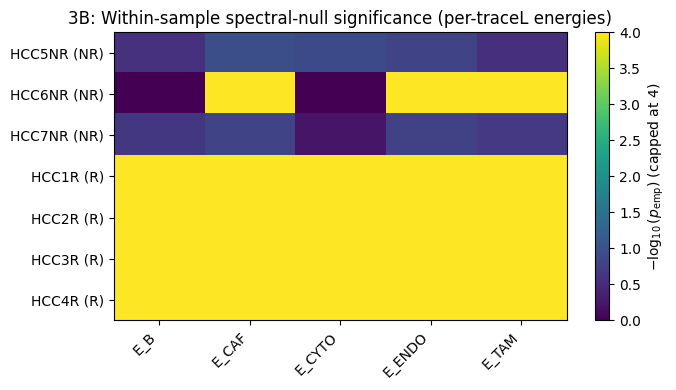

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_within_sample_hires_nperm10000.csv")
df = df[(df["endpoint"]=="per_traceL") & (df["metric"].isin(["E_B","E_CAF","E_CYTO","E_ENDO","E_TAM"]))].copy()

df["neglog10p"] = -np.log10(df["p_emp"].clip(lower=1e-4))  # cap to 4 for p_min

pivot = df.pivot_table(index=["sample","group"], columns="metric", values="neglog10p", aggfunc="first")
pivot = pivot.sort_index(level=1)  # group ordering

fig, ax = plt.subplots(figsize=(7,4))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels([f"{s} ({g})" for (s,g) in pivot.index])

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$-\log_{10}(p_{\mathrm{emp}})$ (capped at 4)")

ax.set_title("3B: Within-sample spectral-null significance (per-traceL energies)")
plt.tight_layout()
plt.savefig("p03_deconv_robustness_outputs/p0_3b_hires/Fig_3B_within_sample_heatmap.png", dpi=300)
plt.show()

In [105]:
dfp = df.copy()
dfp["p_clip"] = dfp["p_emp"].clip(lower=1e-4)
dfp["neglog10p"] = -np.log10(dfp["p_clip"])

summary = dfp.groupby(["sample","group"]).apply(
    lambda g: pd.Series({
        "N_sig_p_lt_0_05": int((g["p_emp"] < 0.05).sum()),
        "sum_neglog10p": float(g["neglog10p"].sum()),
        "median_p": float(g["p_emp"].median())
    })
).reset_index()

print(summary.sort_values(["group","sample"]))
summary.to_csv("p03_deconv_robustness_outputs/p0_3b_hires/Table_3B_within_sample_composite.csv", index=False)

   sample group  N_sig_p_lt_0_05  sum_neglog10p  median_p
4  HCC5NR    NR              0.0       3.800530  0.148785
5  HCC6NR    NR              3.0      12.000000  0.000100
6  HCC7NR    NR              0.0       3.150176  0.217478
0   HCC1R     R              5.0      20.000000  0.000100
1   HCC2R     R              5.0      20.000000  0.000100
2   HCC3R     R              5.0      20.000000  0.000100
3   HCC4R     R              5.0      20.000000  0.000100


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_96499/3221351929.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = dfp.groupby(["sample","group"]).apply(


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


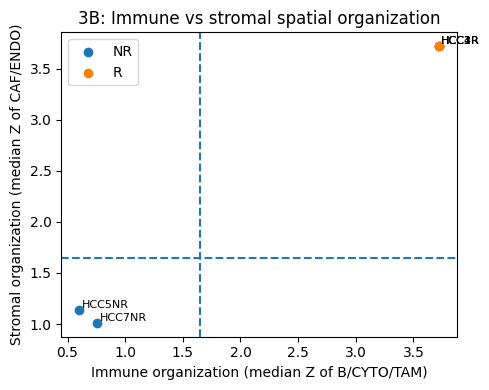

In [106]:
from scipy.stats import norm

dfz = df.copy()
dfz = dfz[(dfz["endpoint"]=="per_traceL") & (dfz["metric"].isin(["E_B","E_CAF","E_CYTO","E_ENDO","E_TAM"]))].copy()
dfz["Z"] = norm.isf(dfz["p_emp"].clip(lower=1e-4))  # one-sided

def medZ(g, metrics):
    return float(g[g["metric"].isin(metrics)]["Z"].median())

rows=[]
for (sample, group), g in dfz.groupby(["sample","group"]):
    rows.append({
        "sample": sample, "group": group,
        "Z_immune": medZ(g, ["E_B","E_CYTO","E_TAM"]),
        "Z_stromal": medZ(g, ["E_CAF","E_ENDO"]),
    })
df_axis = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(5,4))
for grp, sub in df_axis.groupby("group"):
    ax.scatter(sub["Z_immune"], sub["Z_stromal"], label=grp)
for _, r in df_axis.iterrows():
    ax.text(r["Z_immune"]+0.02, r["Z_stromal"]+0.02, r["sample"], fontsize=8)

ax.axvline(1.645, linestyle="--")  # p=0.05 one-sided
ax.axhline(1.645, linestyle="--")
ax.set_xlabel("Immune organization (median Z of B/CYTO/TAM)")
ax.set_ylabel("Stromal organization (median Z of CAF/ENDO)")
ax.set_title("3B: Immune vs stromal spatial organization")
ax.legend()
plt.tight_layout()
plt.savefig("p03_deconv_robustness_outputs/p0_3b_hires/Fig_3B_immune_vs_stromal.png", dpi=300)
plt.show()

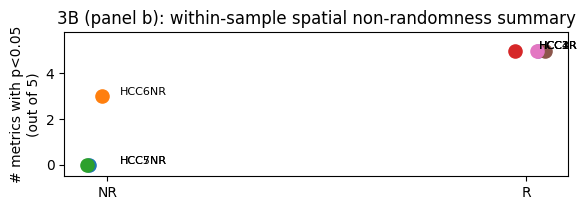

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    "sample": ["HCC5NR","HCC6NR","HCC7NR","HCC1R","HCC2R","HCC3R","HCC4R"],
    "group":  ["NR","NR","NR","R","R","R","R"],
    "N_sig":  [0,3,0,5,5,5,5],
    "sum_neglog10p":[3.80053,12.0,3.150176,20,20,20,20]
})

fig, ax = plt.subplots(figsize=(6,2.2))

# jittered dot plot for N_sig
xmap = {"NR":0, "R":1}
for i, r in summary.iterrows():
    ax.scatter(xmap[r["group"]] + np.random.uniform(-0.05,0.05) , r["N_sig"], s=90)
    ax.text(xmap[r["group"]]+0.03, r["N_sig"]+0.05, r["sample"], fontsize=8)

ax.set_xticks([0,1])
ax.set_xticklabels(["NR","R"])
ax.set_ylabel("# metrics with p<0.05\n(out of 5)")
ax.set_ylim(-0.5,5.8)
ax.set_title("3B (panel b): within-sample spatial non-randomness summary")
plt.tight_layout()
plt.savefig("p03_deconv_robustness_outputs/p0_3b_hires/Fig_3B_Nsig_strip.png", dpi=300)
plt.show()